# COMPX593 Thesis Plot Notebook
This notebook is used to plot figures for COMPX593 Thesis - Fine-Tunning Oxford Nanopore Basecalling Model to Enable High-Fidelity Single-Read Variant Calling in Antibody Libraries

- Heavy BAM-backed analyses are cached under `plot/cache/` so repeat notebook runs stay practical.
- Panels exports are written to `plot/panels/` in SVG format for downstream editing.


# Library Imports & Configuration

In [97]:
from __future__ import annotations
from collections import defaultdict
import sys
import gzip
import math
import re
import subprocess
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

# Global style configuration
def configure_matplotlib() -> None:
    """matching matplotlib as in PlotSignal.py"""
    plt.rcParams.update(
        {
            "font.family": "DejaVu Serif",
            "font.size": 10,
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "axes.labelweight": "normal",
            "axes.titleweight": "normal",
            "axes.linewidth": 0.8,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "xtick.direction": "out",
            "ytick.direction": "out",
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "xtick.minor.width": 0.6,
            "ytick.minor.width": 0.6,
            "xtick.major.size": 4,
            "ytick.major.size": 4,
            "xtick.minor.size": 2.5,
            "ytick.minor.size": 2.5,
            "figure.facecolor": "white",
            "figure.dpi": 120,
            "axes.facecolor": "white",
            "axes.edgecolor": "#222222",
            "axes.grid": False,
            "grid.color": "#d9d9d9",
            "grid.linewidth": 0.6,
            "grid.alpha": 0.7,
            "legend.fontsize": 10,
            "savefig.facecolor": "white",
            "savefig.edgecolor": "white",
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.03,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "svg.fonttype": "none",
        }
    )


configure_matplotlib()

# Configure root directory and relevant data folder
ROOT = Path("/home/kang/experimental/COMPX593-Thesis/plot")
DATA_DIR = ROOT / "data"
TEST_DIR = ROOT / "test"
CACHE_DIR = ROOT / "cache"
PANELS_DIR = ROOT / "panels"
REFERENCE_FASTA = DATA_DIR / "fc_reference.fa"
DMS_ZONE_FILE = DATA_DIR / "DMSZones.txt"

# Create cache and figure directory if they not exist
CACHE_DIR.mkdir(exist_ok=True)
PANELS_DIR.mkdir(exist_ok=True)
(CACHE_DIR / "fastq_samples").mkdir(exist_ok=True)
(CACHE_DIR / "mutation_density").mkdir(exist_ok=True)

# Create a fixed display order for all models/data in test.csv
DISPLAY_ORDER = [
    "Alpha",
    "AlphaQCH",
    "AlphaQCL",
    "Gamma",
    "GammaQCH",
    "GammaQCL",
    "Beta",
    "BetaQCH",
    "BetaQCL",
    "sup",
    "UDP0057",
]

# Create a fixed display order for only model in test.csv
MODEL_ONLY_ORDER = [name for name in DISPLAY_ORDER if name != "UDP0057"]

# Create a fixed display order for datasets in data.csv
DATASET_ORDER = [
    "A_full",
    "A_filtered",
    "AB_full",
    "AB_filtered",
    "B_full",
    "B_filtered",
    "2025_07_31",
    "UDP0057",
]

# Create a fixed display order for dataset searching
DISPLAY_TO_RAW = {name: name for name in MODEL_ONLY_ORDER}
DISPLAY_TO_RAW["UDP0057"] = "UDP0057.fq"

# Create a sort order for sorting by name later (sort by custome order)
SORT_ORDER = {name: idx for idx, name in enumerate(DISPLAY_ORDER + DATASET_ORDER)}

# Pick only 1 color for each family (e.g., model and dataset)
FAMILY_COLORS = {
    "Alpha": "#1b9e77",
    "Gamma": "#d95f02",
    "Beta": "#4c78a8",
    "sup": "#7f7f7f",
    "UDP0057": "#111111",
    "A_full": "#4c78a8",
    "A_filtered": "#4c78a8",
    "AB_full": "#1b9e77",
    "AB_filtered": "#1b9e77",
    "B_full": "#d95f02",
    "B_filtered": "#d95f02",
    "2025_07_31": "#8c564b",
}

# For all scatter plot use a fix set of marker for consistancy
VARIANT_MARKERS = {
    # Alpha, Beta, Gamma
    "base": "o",
    # AlphaQCH, BetaQCH, GammaQCH
    "QCH": "s",
    # AlphaQCL, BetaQCL, GammaQCL
    "QCL": "D",
    # sup
    "sup": "X",
    # UDP0057
    "reference": "P",
}

# Define fixed region colour for DMS and Framework.
REGION_COLORS = {"DMS": "#c44e52", "Framework": "#4c72b0"}

# Configure table 
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")


# Utilities

In [98]:
def coerce_numeric(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        if out[col].dtype != object:
            continue
        try:
            out[col] = pd.to_numeric(out[col])
        except (TypeError, ValueError):
            pass
    return out

model_raw = coerce_numeric(pd.read_csv(ROOT / "model.csv"))
MODEL_FAMILY_LOOKUP = model_raw.set_index("name")["family"].to_dict()
MODEL_VARIANT_LOOKUP = model_raw.set_index("name")["variant"].to_dict()

# Remove file suffix from filenames
def normalize_display_name(name: str) -> str:
    stem = str(name)
    for suffix in (".fastq.gz", ".fq.gz", ".fastq", ".fq", ".pod5", ".bam", ".tsv"):
        if stem.endswith(suffix):
            stem = stem[: -len(suffix)]
            break
    return stem

# this function standardise dataframes (data.csv, test.csv, model.csv, correlation.csv) with the same metadata columns, so the rest of the notebook can ssume these fields exist
# display_name (a clean label like UDP0057 without file extension)
# family (grouping for color, like Alpha, Beta, Gamma, sup)
# variant (grouping for marker shape, like base, QCH, QCL, sup, reference)
# sort_order (stable ordering for plots and tables)
def add_display_metadata(df: pd.DataFrame) -> pd.DataFrame:
    # make a deep of the data frame
    out = df.copy()
    # normalise the display name (trim of any file extension)
    out["display_name"] = out["name"].map(normalize_display_name)
    # if dataframe doesn't have family column, use MODEL_FAMILY_LOOKUP dictionary to append family column
    if "family" not in out.columns:
        out["family"] = out["name"].map(MODEL_FAMILY_LOOKUP)
    out["family"] = out["family"].fillna(out["display_name"])
    # special-case sup and UDP0057
    out.loc[out["display_name"] == "sup", "family"] = "sup"
    out.loc[out["display_name"] == "UDP0057", "family"] = "UDP0057"
    # if dataframe doesn't have variant column, use MODEL_VARIANT_LOOKUP dictionary to append variant column
    if "variant" not in out.columns:
        out["variant"] = out["name"].map(MODEL_VARIANT_LOOKUP)
    out["variant"] = out["variant"].fillna("base")
    # special-case sup and UDP0057
    out.loc[out["display_name"] == "sup", "variant"] = "sup"
    out.loc[out["display_name"] == "UDP0057", "variant"] = "reference"
    # compute sort_order column from predefined plotting order list
    out["sort_order"] = out["display_name"].map(SORT_ORDER).fillna(999).astype(int)
    # returns the dataframe sorted and reindexed
    return out.sort_values(["sort_order", "display_name"]).reset_index(drop=True)


def load_reference_sequence(reference_path: Path = REFERENCE_FASTA) -> str:
    parts = []
    with reference_path.open() as handle:
        for line in handle:
            if line.startswith(">"):
                continue
            parts.append(line.strip())
    return "".join(parts)


def parse_dms_zones(zone_path: Path = DMS_ZONE_FILE) -> list[tuple[int, int]]:
    raw = zone_path.read_text().strip()
    zones = []
    for chunk in raw.split(","):
        start, end = chunk.split("-")
        zones.append((int(start), int(end)))
    return zones


REFERENCE_SEQUENCE = load_reference_sequence()
REFERENCE_LENGTH = len(REFERENCE_SEQUENCE)
DMS_ZONES = parse_dms_zones()
# Create a list represent joined DMS segments
JOINED_DMS_SEGMENTS = []
joined_dms_offset = 0
for start, end in DMS_ZONES:
    segment_length = end - start + 1
    JOINED_DMS_SEGMENTS.append(
        {
            "start": start,
            "end": end,
            "joined_start": joined_dms_offset + 1,
            "joined_end": joined_dms_offset + segment_length,
            "joined_mid": joined_dms_offset + (segment_length + 1) / 2.0,
        }
    )
    joined_dms_offset += segment_length
JOINED_DMS_LENGTH = joined_dms_offset

# determine whether a nucleotide position is within the DMS zone or not.
def position_region(position_1based: int) -> str:
    for start, end in DMS_ZONES:
        if start <= position_1based <= end:
            return "DMS"
    return "Framework"


def joined_dms_position(position_1based: int) -> float:
    for segment in JOINED_DMS_SEGMENTS:
        if segment["start"] <= position_1based <= segment["end"]:
            # convert the global base position to local base position in relation to joined DMS regions
            return float(segment["joined_start"] + (position_1based - segment["start"]))
    return np.nan

# iterates through all subdirectories in TEST_DIR
# filters to only directories that contan an underscore in their name
# for each matching directory, splits the name on the first underscore and use the second part as the key
TEST_ARTIFACTS = {
    path.name.split("_", 1)[1]: path
    for path in TEST_DIR.iterdir()
    if path.is_dir() and "_" in path.name
}

# iterate through all subdirectories in DATA_DIR
# simply use the directory name as both key and value.
DATA_ARTIFACTS = {path.name: path for path in DATA_DIR.iterdir() if path.is_dir()}

# resolve test directory for a internal display name
def resolve_test_dir(name: str) -> Path:
    raw_name = DISPLAY_TO_RAW.get(name, name)
    # return the correct directory for the given display name
    return TEST_ARTIFACTS[raw_name]

# resolve the bam file as either primary aligned or polished aligned
def resolve_bam_path(name: str, stage: str = "primary") -> Path:
    model_dir = resolve_test_dir(name)
    if stage == "primary":
        suffix = "*.aligned.bam"
    elif stage == "polished":
        suffix = "*.polished.sorted.bam"
    else:
        raise ValueError(f"Unsupported stage: {stage}")
    matches = sorted(model_dir.glob(suffix))
    if len(matches) != 1:
        raise FileNotFoundError(f"Expected exactly one {suffix} in {model_dir}, found {len(matches)}")
    # return the exact .bam file located
    return matches[0]

# find the return that path to corresponding variant key file for any given dataset/model
def resolve_variant_path(name: str) -> Path:
    model_dir = resolve_test_dir(name)
    matches = sorted(model_dir.glob("*.variants.tsv"))
    if len(matches) != 1:
        raise FileNotFoundError(f"Expected exactly one *.variants.tsv in {model_dir}, found {len(matches)}")
    return matches[0]

# Method use to save figure in .svg with a dip of 300
def save_figure(fig: plt.Figure, stem: str, *, dpi: int = 300) -> Path:
    output_path = FIGURES_DIR / f"{stem}.svg"
    fig.savefig(output_path, dpi=dpi, format="svg")
    return output_path

# define a function to return family color with a default alternative
def family_color(name_or_family: str) -> str:
    return FAMILY_COLORS.get(name_or_family, "#444444")


def lighten_color(color: str, amount: float = 0.55) -> tuple[float, float, float]:
    base = np.asarray(mpl.colors.to_rgb(color))
    return tuple(base + (1.0 - base) * amount)

# shading the DMS regions with saved color
def add_dms_shading(ax: plt.Axes, *, alpha: float = 0.10) -> None:
    for start, end in DMS_ZONES:
        ax.axvspan(start, end, color=REGION_COLORS["DMS"], alpha=alpha, lw=0)

# this function calculates the maximumm size of nodes to accomodate both incoming and outgoing follows from that nodes
def _sankey_node_group_values(
    links: list[dict[str, object]],
    group_order: list[str],
) -> dict[str, dict[str, float]]:
    # total value flowing into a node from a specific dataset/group
    incoming: dict[str, dict[str, float]] = defaultdict(lambda: defaultdict(float))
    # total value flowing out of a node to a specific group
    outgoing: dict[str, dict[str, float]] = defaultdict(lambda: defaultdict(float))
    # process each link
    for link in links:
        # the source filter/node
        source = str(link["source"])
        # the target filter/node
        target = str(link["target"])
        # the dataset/group
        group = str(link["group"])
        # the number of reads flowing
        value = float(link["value"])
        # add to the source node outgoing dataset/group
        outgoing[source][group] += value
        # add to the target node incoming dataset/group
        incoming[target][group] += value

    node_values: dict[str, dict[str, float]] = {}
    # for each node (any node that appears as either source or target)
    for node in set(incoming) | set(outgoing):
        node_values[node] = {}
        # for each group in specific order
        for group in group_order:
            # take the maximum of incoming vs outgoing value for that group
            # this ensures the node segment is large enough to accommodate both incoming and outgoing flows
            node_values[node][group] = max(incoming[node][group], outgoing[node][group])
    return node_values



def _sankey_scale(
    columns: list[list[str]],
    node_group_values: dict[str, dict[str, float]],
    *,
    usable_height: float = 0.82,
    node_gap: float = 0.035,
) -> float:
    scales = []
    for column_nodes in columns:
        # calculating the height of the column to accomodate required nodes
        column_total = sum(sum(node_group_values[node].values()) for node in column_nodes)
        # calculating number of gaps required for the column
        gap_total = node_gap * max(0, len(column_nodes) - 1)
        # calculating vailable space then scale to make this column fit perfectly
        scales.append((usable_height - gap_total) / column_total)
    # return the most restrictive scale
    # the most constrained column (one with the largest total value) determines the overall scale
    return min(scales)



def _sankey_layouts(
    column_x: list[float],
    columns: list[list[str]],
    node_group_values: dict[str, dict[str, float]],
    group_order: list[str],
    *,
    scale: float,
    node_gap: float = 0.035,
) -> dict[str, dict[str, object]]:
    layouts: dict[str, dict[str, object]] = {}
    for x, column_nodes in zip(column_x, columns):
        # calculate the total height of that node with scale factor
        total_height = sum(sum(node_group_values[node].values()) * scale for node in column_nodes)
        # include the gap height too for each column
        total_height += node_gap * max(0, len(column_nodes) - 1)
        # center the column vertically
        y_cursor = 0.5 + total_height / 2.0
        # for each individual node in a column
        for node in column_nodes:
            # compute the individual node height with scale factor
            node_height = sum(node_group_values[node].values()) * scale
            # place the node at current cursor position
            y_top = y_cursor
            # updates cursor downward for next node
            y_bottom = y_top - node_height
            # create a segment cursor for each dataset/group/flow
            seg_cursor = y_top
            segments: dict[str, tuple[float, float]] = {}
            # within each node, stacks colored segments from top to bottom
            # following the group_order specified
            for group in group_order:
                # each segment's height is proportional to its value
                seg_height = node_group_values[node].get(group, 0.0) * scale
                # anchor the segment
                seg_top = seg_cursor
                # determine the buttom of the segement
                seg_bottom = seg_top - seg_height
                # add a segment to segments for drawing
                segments[group] = (seg_bottom, seg_top)
                # update the cursor location to the buttom of this segment (prepare to start next segment)
                seg_cursor = seg_bottom
            # save the nodes complete layout infor for drawing later
            layouts[node] = {"x": x, "y0": y_bottom, "y1": y_top, "segments": segments}
            # move the cursor down by node height + gap for next node
            y_cursor = y_bottom - node_gap
    # for the layouts for all columns (i.e., nodes)
    return layouts


# define ribbon function that return a mpl PathPatch for drawing
def _sankey_ribbon_patch(
    x0: float,
    x1: float,
    y0_bottom: float,
    y0_top: float,
    y1_bottom: float,
    y1_top: float,
    *,
    color: str,
    alpha: float,
) -> mpl.patches.PathPatch:
    # distance between columns/filters
    dx = x1 - x0
    # move the control point 38% in the horizontal distance from each edge (smooth, flowing ribbon shape)
    curvature = dx * 0.38
    # allocate some vertices 
    vertices = [
        # top left corner
        (x0, y0_top),
        # curve start
        (x0 + curvature, y0_top),
        # curve end
        (x1 - curvature, y1_top),
        # top right corner
        (x1, y1_top),
        # buttom right corner
        (x1, y1_bottom),
        # curve start
        (x1 - curvature, y1_bottom),
        # curve end
        (x0 + curvature, y0_bottom),
        # buttom left cornor
        (x0, y0_bottom),
        # back to start
        (x0, y0_top),
    ]
    # define path code
    codes = [
        # linear
        mpl.path.Path.MOVETO,
        # cubic Bezier curve (3 control point, current vertex + 3 more)
        mpl.path.Path.CURVE4,
        # cubic Bezier curve (3 control point, current vertex + 3 more)
        mpl.path.Path.CURVE4,
        # cubic Bezier curve (3 control point, current vertex + 3 more)
        mpl.path.Path.CURVE4,
        # linear
        mpl.path.Path.LINETO,
        # cubic Bezier curve (3 control point, current vertex + 3 more)
        mpl.path.Path.CURVE4,
        # cubic Bezier curve (3 control point, current vertex + 3 more)
        mpl.path.Path.CURVE4,
        # cubic Bezier curve (3 control point, current vertex + 3 more)
        mpl.path.Path.CURVE4,
        # connects back to the start automatically
        mpl.path.Path.CLOSEPOLY,
    ]
    # create and return the patch
    return mpl.patches.PathPatch(
        mpl.path.Path(vertices, codes),
        facecolor=color,
        edgecolor="none",
        alpha=alpha,
    )


# allocate each links to corresponding segment in layouts
def _sankey_allocate_links(
    links: list[dict[str, object]],
    layouts: dict[str, dict[str, object]],
    group_order: list[str],
    *,
    scale: float,
) -> list[dict[str, object]]:
    outgoing: dict[tuple[str, str], list[dict[str, object]]] = defaultdict(list)
    incoming: dict[tuple[str, str], list[dict[str, object]]] = defaultdict(list)
    # we only need to know the source filter, target filter and dataset/group of each link (value is not necessary here, as segment height has been pre-computed)
    for link in links:
        source = str(link["source"])
        target = str(link["target"])
        group = str(link["group"])
        outgoing[(source, group)].append(link)
        incoming[(target, group)].append(link)

    # process outgoing links
    for (source, group), subset in outgoing.items():
        # sort links so those going to targets with higher y1 (top) come first
        subset.sort(key=lambda item: layouts[str(item["target"])]["y1"], reverse=True)
        # retrieves the vertical range of the colored segment for this group in the source node
        seg_bottom, seg_top = layouts[source]["segments"][group]
        # anchor the cursor to the top of this segment
        cursor = seg_top
        # for each link (in sorted order)
        for item in subset:
            # calculate ribbon height proportion to its value
            height = float(item["value"]) * scale
            # determine top of the ribbon (current cursor position)
            item["source_y1"] = cursor
            # determine buttom of the ribbon
            item["source_y0"] = cursor - height
            # update the cursor location
            cursor -= height
        # validate allocation
        # after all ribbons are placed, cursor should equal seg_buttom
        # a tiny tolerance accounts for floating-point rounding.
        if abs(cursor - seg_bottom) > 1e-7:
            raise ValueError(f"Outgoing Sankey allocation mismatch for {source} / {group}")

    # process incoming links
    for (target, group), subset in incoming.items():
        subset.sort(key=lambda item: layouts[str(item["source"])]["y1"], reverse=True)
        seg_bottom, seg_top = layouts[target]["segments"][group]
        cursor = seg_top
        for item in subset:
            height = float(item["value"]) * scale
            item["target_y1"] = cursor
            item["target_y0"] = cursor - height
            cursor -= height
        if abs(cursor - seg_bottom) > 1e-7:
            raise ValueError(f"Incoming Sankey allocation mismatch for {target} / {group}")
    # return the processed links
    return links


# add patches to sankey nodes and segments
def _add_sankey_nodes(
    ax: plt.Axes,
    layouts: dict[str, dict[str, object]],
    node_group_values: dict[str, dict[str, float]],
    group_order: list[str],
    group_colors: dict[str, str],
    *,
    node_width: float = 0.028,
) -> None:
    for node, layout in layouts.items():
        x = float(layout["x"])
        y0 = float(layout["y0"])
        y1 = float(layout["y1"])
        # each node will be draw as white rectangle
        ax.add_patch(
            mpl.patches.Rectangle(
                (x - node_width / 2.0, y0),
                node_width,
                y1 - y0,
                facecolor="white",
                edgecolor="#4f4f4f",
                linewidth=0.8,
                zorder=5,
            )
        )
        # for each segment inside the nodes
        for group in group_order:
            value = node_group_values[node].get(group, 0.0)
            if value <= 0:
                continue
            seg_bottom, seg_top = layout["segments"][group]
            # each segment will be draw using the dataset color
            ax.add_patch(
                mpl.patches.Rectangle(
                    (x - node_width / 2.0, seg_bottom),
                    node_width,
                    seg_top - seg_bottom,
                    facecolor=group_colors[group],
                    edgecolor="white",
                    linewidth=0.35,
                    alpha=0.28,
                    zorder=6,
                )
            )


# Function use to draw a sankey graph
def draw_segmented_sankey(
    # the axes object to plot the sankey graph in
    ax: plt.Axes,
    # everything after this must be passed as keyword argument
    *,
    # a list of note columns
    columns: list[list[str]],
    # the x-position of each column (between 0 and 1)
    column_x: list[float],
    # the flow record between note
    links: list[dict[str, object]],
    # the order in which dataset groups are stacked and drawn
    group_order: list[str],
    # a dictionary mapping each group name to a color
    group_colors: dict[str, str],
    # a dictionary mapping internal nodes name to display labels
    node_labels: dict[str, str],
    # optional manual label placement override
    label_positions: dict[str, dict[str, object]] | None = None,
    # option width of each sankey node rectange.
    node_width: float = 0.028,
) -> None:
    # calculate accomodating node size for each node
    node_group_values = _sankey_node_group_values(links, group_order)
    # minimum scale across all columns 
    scale = _sankey_scale(columns, node_group_values)
    # calculating layout for each column (x position, y bottom and y top, segments within each node)
    layouts = _sankey_layouts(column_x, columns, node_group_values, group_order, scale=scale)
    # process each link to map to location in the drawed segment
    allocated_links = _sankey_allocate_links(links, layouts, group_order, scale=scale)

    # for each link create a path patch for drawing
    for link in allocated_links:
        source = str(link["source"])
        target = str(link["target"])
        group = str(link["group"])
        ax.add_patch(
            _sankey_ribbon_patch(
                float(layouts[source]["x"]),
                float(layouts[target]["x"]),
                float(link["source_y0"]),
                float(link["source_y1"]),
                float(link["target_y0"]),
                float(link["target_y1"]),
                color=group_colors[group],
                alpha=0.86,
            )
        )

    # create patches for nodes and segment inside the nodes
    _add_sankey_nodes(ax, layouts, node_group_values, group_order, group_colors, node_width=node_width)

    # for each node to label mapping in node_labels
    for node, label in node_labels.items():
        # first check if there is position override for label
        override = (label_positions or {}).get(node, {})
        if override:
            ax.text(
                float(override["x"]),
                float(override["y"]),
                label,
                ha=str(override.get("ha", "left")),
                va=str(override.get("va", "center")),
                color="#222222",
            )
            continue
        # find the node location using layouts
        layout = layouts[node]
        # anchor the lable around middle of the node
        x = float(layout["x"])
        y = (float(layout["y0"]) + float(layout["y1"])) / 2.0
        # if the node is to the right edge of the drawing area, draw the label to the left of the node
        if x > 0.78:
            ax.text(x - 0.026, y, label, ha="right", va="center", color="#222222")
        # if the node is to the left/middle of the drawing area, draw the label to the right of the node
        else:
            ax.text(x + 0.026, y, label, ha="left", va="center", color="#222222")

    # normalise coordinate system
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.axis("off")


def build_legend_handles(include_reference: bool = True) -> tuple[list[Line2D], list[Line2D]]:
    families = ["Alpha", "Gamma", "Beta", "sup"] + (["UDP0057"] if include_reference else [])
    family_handles = [
        Line2D([0], [0], color=family_color(fam), lw=3, label=fam)
        for fam in families
    ]
    variant_handles = [
        Line2D(
            [0],
            [0],
            color="#333333",
            marker=marker,
            lw=0,
            ms=8,
            label=label,
        )
        for label, marker in [("base", "o"), ("QCH", "s"), ("QCL", "D"), ("sup", "X"), ("reference", "P")]
        if include_reference or label != "reference"
    ]
    return family_handles, variant_handles

# format the model/dataset label to add space for axis-label
def format_model_label(display_name: str) -> str:
    return display_name.replace("QCH", "\nQCH").replace("QCL", "\nQCL").replace("UDP0057", "UDP\n0057")

# this link the label name for the model to the actual display_name (metadata) of the model
MODEL_LABEL_FAMILY_LOOKUP = {}
for name in DISPLAY_ORDER:
    family = MODEL_FAMILY_LOOKUP.get(name, name)
    MODEL_LABEL_FAMILY_LOOKUP[name] = family
    MODEL_LABEL_FAMILY_LOOKUP[format_model_label(name)] = family

# return the model family given the model label
def model_family_from_label(label: str) -> str | None:
    text = str(label).strip()
    if not text:
        return None
    normalized = text.replace("\n", "")
    return MODEL_LABEL_FAMILY_LOOKUP.get(text) or MODEL_LABEL_FAMILY_LOOKUP.get(normalized)

# set the color the model label in x and y axis to use the model family color
def color_model_ticklabels(ax: plt.Axes, axis: str = "both") -> None:
    if axis in {"x", "both"}:
        for tick in ax.get_xticklabels():
            family = model_family_from_label(tick.get_text())
            if family is not None:
                tick.set_color(family_color(family))
    if axis in {"y", "both"}:
        for tick in ax.get_yticklabels():
            family = model_family_from_label(tick.get_text())
            if family is not None:
                tick.set_color(family_color(family))

# set the color the plot title using model family color (i.e., panel B, plot 3.8)
def color_model_title(ax: plt.Axes) -> None:
    family = model_family_from_label(ax.get_title())
    if family is not None:
        ax.title.set_color(family_color(family))

# use fixed marker sizes for model-level scatter plots now that unique-variant-driven sizing is retired
MODEL_MARKER_SIZE = 180
RANK_MARKER_SIZE = 120


def orient_and_scale_metrics(df: pd.DataFrame, metric_specs: list[tuple[str, str, bool]]) -> pd.DataFrame:
    scaled = {}
    for column, label, higher_is_better in metric_specs:
        # extract the column from dataframe and convert it to a float series
        series = df[column].astype(float)
        # if lower is better (e.g., error_rate) then negate the series (so the largest positive number become smallest negative number)
        oriented = series if higher_is_better else -series
        # determine the normalisation range
        # take the min value
        min_value = oriented.min()
        # take the max value
        max_value = oriented.max()
        # determine whether values are closer than 1e-9
        if math.isclose(min_value, max_value):
            scaled[label] = pd.Series(np.ones(len(series)), index=df.index)
        else:
            scaled[label] = (oriented - min_value) / (max_value - min_value)
    return pd.DataFrame(scaled, index=df.index)

# computing z-score for z-score based heatmap
def zscore_metrics(df: pd.DataFrame, metric_specs: list[tuple[str, str, bool]]) -> pd.DataFrame:
    zscores = {}

    for column, label, higher_is_better in metric_specs:    
        # extract the column from dataframe and convert it to a float series
        series = df[column].astype(float)
        # if lower is better (e.g., error_rate) than negate the series (so the largest positive number become smallest negative number)
        oriented = series if higher_is_better else -series
        # calculating standard deviation
        std = oriented.std(ddof=0)
        # if standard deviation is close to 0 (all values identical), assigns z-score of 0 to all
        if math.isclose(std, 0.0):
            zscores[label] = pd.Series(np.zeros(len(oriented)), index=df.index)
        else:
            # otherwise compute the z-score (how many standard deviation away)
            zscores[label] = (oriented - oriented.mean()) / std
    # return a dataframe of zscores with the same df index as the input dataframe)
    return pd.DataFrame(zscores, index=df.index)

# return a input stream from given fastq file, compressed fastq supported.
def open_fastq(path: Path):
    if str(path).endswith(".gz"):
        return gzip.open(path, "rt")
    return path.open()

# used by load_fastq_distribution() to locate the correct .fq or .fastq file for a particular fitler.
def resolve_data_fastq(name: str, filter: str) -> Path:
    # remove file extension
    stem = normalize_display_name(name)
    # Chooses candidate file path (data/<stem>.fastq or data/<stem>.fq or data/<stem>/<stem>.basecalled.fq)
    if filter == "pre_length_filter":
        candidates = [DATA_DIR / f"{stem}.fastq", DATA_DIR / f"{stem}.fq", DATA_ARTIFACTS.get(stem, Path()) / f"{stem}.basecalled.fq"]
    # post_length_filter, post_quality_filter, and post_alignment filter data has only be found in data/<stem>/
    elif filter == "post_length_filter":
        candidates = [DATA_ARTIFACTS[stem] / f"{stem}.len600_800.fq"]
    elif filter == "post_quality_filter":
        candidates = [DATA_ARTIFACTS[stem] / f"{stem}.q15.fq"]
    elif filter == "post_alignment_filter":
        candidates = [DATA_ARTIFACTS[stem] / f"{stem}.aligned.fq"]
    # if no candiate file found, then the filter is not supported.
    else:
        raise ValueError(f"Unsupported stage: {filter}")

    # If there are multiple candidate, choose the one that exist
    for candidate in candidates:
        if candidate and candidate.exists():
            return candidate
    raise FileNotFoundError(f"No FASTQ found for {name} at stage {filter}")

# used by build_model_mean_q_summary() to locate model FASTQ artifacts in plot/test/.
def resolve_test_fastq(name: str, filter: str) -> Path:
    # locate the correct test directory for the given model/dataset.
    model_dir = resolve_test_dir(name)
    # use the directory name as the root file name (each test file start with the directory name as prefix)
    stem = model_dir.name
    if filter == "pre_length_filter":
        candidates = [model_dir / f"{stem}.basecalled.fq"]
    elif filter == "post_length_filter":
        candidates = [model_dir / f"{stem}.len600_800.fq"]
    elif filter == "post_alignment_filter":
        candidates = [model_dir / f"{stem}.aligned.fq"]
    elif filter == "post_dms_filter":
        candidates = [model_dir / f"{stem}.polished.fq"]
    else:
        raise ValueError(f"Unsupported stage: {filter}")

    # make sure the file actually exist before return it.
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"No model FASTQ found for {name} at stage {filter}")

# UDP0057 are 2x300 paired-end illumina read that joined together using WT nucleotide with # score.
# these low quality WT nucleotide need to be trim to prevent impact on quality calculation
def trim_long_q2_runs(q_array: np.ndarray, *, min_run_length: int = 20) -> np.ndarray:
    if len(q_array) == 0:
        return q_array

    keep_mask = np.ones(len(q_array), dtype=bool)
    run_start = None
    for idx, score in enumerate(q_array):
        # if the current nucleotide has a score of 2 and the run haven't start; start counting/run
        if score == 2 and run_start is None:
            run_start = idx
        # if the current nucleotide has a score that's not 2 and the run has started; check to see if the len(run) >= min_run_length
        elif score != 2 and run_start is not None:
            if idx - run_start >= min_run_length:
                keep_mask[run_start:idx] = False
            run_start = None

    if run_start is not None and len(q_array) - run_start >= min_run_length:
        keep_mask[run_start:] = False

    return q_array[keep_mask]

# This function loads a read-level q-score from a FASTQ file.
def load_mean_q(path: Path, sample_size: int) -> pd.DataFrame:
    mean_q = []
    trim_q2_bridge = "UDP0057" in path.name or "UDP0057" in str(path.parent)
    with open_fastq(path) as handle:
        while len(mean_q) < sample_size:
            # read the fastq header
            header = handle.readline()
            # if header doesn't exist break (EOF)
            if not header:
                break
            # read the sequence
            handle.readline()
            # read the + sign, ignore the results
            handle.readline()
            # read the quality score, strip the spaces at both ends
            quality = handle.readline().strip()
            # convert ASCII qualities to Phred scores.
            q_array = (np.frombuffer(quality.encode("ascii"), dtype=np.uint8) - 33).astype(np.float64)
            # UDP0057 includes an intentionally injected WT bridge marked as a long Q2 run.
            # Remove that synthetic segment so the read-level score reflects sequenced bases only.
            if trim_q2_bridge:
                q_array = trim_long_q2_runs(q_array)
            # read-level Q-score must be computed from the mean error probability,
            # not from the arithmetic mean of Phred scores.
            if len(q_array):
                mean_error_probability = np.power(10.0, -q_array / 10.0).mean()
                mean_q.append(float(-10.0 * np.log10(mean_error_probability)))
            else:
                mean_q.append(np.nan)
    # return a disctionary with read_length mapped to lengths list and mean_q mapped to mean_q list.
    # Pandas uses that dict to create columns in the DataFrame. So the results is a table with two columns.
    return pd.DataFrame({"mean_q": mean_q})

# This function loads length and mean q-score for each reads in fastq/fq files found in source_df
def load_fastq_distribution(
    source_df: pd.DataFrame,
    sample_size: int
) -> pd.DataFrame:
    if sample_size == sys.maxsize:
        cache_path = CACHE_DIR / "fastq_samples" / "dataset_all_read_level_mean_q.csv"
    else:
        cache_path = CACHE_DIR / "fastq_samples" / f"dataset_head_{sample_size}_read_level_mean_q.csv"

    dataset_order = [name for name in DATASET_ORDER if name in source_df["display_name"].tolist()]
    requested_pairs = [
        (row["display_name"], FASTQ_STAGE_LABELS[filter_name])
        for _, row in source_df.sort_values("sort_order").iterrows()
        if row["display_name"] in DATASET_ORDER
        for filter_name in ["pre_length_filter", "post_alignment_filter"]
    ]

    cached_pairs: set[tuple[str, str]] = set()
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        cached_pairs = set(zip(cached["dataset"], cached["filter"]))

    for _, row in source_df.sort_values("sort_order").iterrows():
        stem = row["display_name"]
        if stem not in DATASET_ORDER:
            continue
        for filter_name in ["pre_length_filter", "post_alignment_filter"]:
            filter_label = FASTQ_STAGE_LABELS[filter_name]
            if (stem, filter_label) in cached_pairs:
                continue
            stage_path = resolve_data_fastq(row["name"], filter_name)
            sampled = load_mean_q(stage_path, sample_size)
            sampled["dataset"] = stem
            sampled["filter"] = filter_label
            sampled.to_csv(cache_path, mode="a", header=not cache_path.exists(), index=False)
            cached_pairs.add((stem, filter_label))

    fastq_df = pd.read_csv(cache_path)
    fastq_df = fastq_df[
        fastq_df["dataset"].isin(dataset_order)
        & fastq_df["filter"].isin(FASTQ_STAGE_LABELS.values())
    ].copy()
    fastq_df["dataset"] = pd.Categorical(fastq_df["dataset"], categories=dataset_order, ordered=True)
    return fastq_df.sort_values(["dataset", "filter"]).reset_index(drop=True)

# This function computes a single mean per-read Q-score summary for each plotted test entry.
def build_model_mean_q_summary(
    source_df: pd.DataFrame,
    filter: str,
    sample_size: int,
) -> pd.DataFrame:
    cache_path = CACHE_DIR / "fastq_samples" / f"model_mean_q_{filter}.csv"
    requested_names = [name for name in source_df["display_name"].tolist() if name in DISPLAY_ORDER]
    cached_lookup: dict[str, dict[str, object]] = {}

    if sample_size == sys.maxsize and cache_path.exists():
        cached_df = coerce_numeric(pd.read_csv(cache_path))
        cached_lookup = {
            str(row["display_name"]): row.to_dict()
            for _, row in cached_df.iterrows()
        }
        if set(requested_names).issubset(cached_lookup):
            return (
                pd.DataFrame([cached_lookup[name] for name in requested_names])
                .sort_values("sort_order")
                .reset_index(drop=True)
            )

    rows = []
    for _, row in source_df.sort_values("sort_order").iterrows():
        stem = row["display_name"]
        if stem not in DISPLAY_ORDER:
            continue
        if sample_size == sys.maxsize and stem in cached_lookup:
            rows.append(cached_lookup[stem])
            continue

        stage_path = resolve_test_fastq(row["name"], filter)
        sampled = load_mean_q(stage_path, sample_size)
        record = {
            "display_name": stem,
            "family": row["family"],
            "variant": row["variant"],
            "sort_order": row["sort_order"],
            "mean_per_read_q": float(sampled["mean_q"].mean()),
            "reads_sampled": len(sampled),
        }
        rows.append(record)

        if sample_size == sys.maxsize:
            cached_lookup[stem] = record
            (
                pd.DataFrame(cached_lookup.values())
                .sort_values("sort_order")
                .to_csv(cache_path, index=False)
            )

    return pd.DataFrame(rows).sort_values("sort_order").reset_index(drop=True)

# this function load the abundance (count or count/total count) for each variant across a variant key tsv file
def load_variant_abundance(
    name: str,
    threshold: int,
    exclude_wt: bool,
    normalize: bool,
) -> pd.DataFrame:
    # locate the variant key file
    path = resolve_variant_path(name)
    # reads the tsv file (separate by \t)
    df = pd.read_csv(path, sep="\t")
    # convert the count column to integer
    df["count"] = df["count"].astype(int)
    # create a new dataframe for rows where count > threshold
    df = df[df["count"] >= threshold].copy()
    # if WT is excluded, create a new dataframe exclude the row for WT
    if exclude_wt:
        df = df[df["variant_key"] != "WT"].copy()
    # compute the total counts across all variant
    total = df["count"].sum()
    # if normlisation is required, compute abundance of that variant
    if normalize and total > 0:
        df["abundance"] = df["count"] / total
    else:
        # otherwise abundance is just the raw count
        df["abundance"] = df["count"].astype(float)
    # create an extra column as diaplay_name for universal access
    df["display_name"] = normalize_display_name(name)
    # return the dataframe sorted by number of counts in decending order with new index
    return df.sort_values("count", ascending=False).reset_index(drop=True)


def build_shared_variant_scatter(
    model_names: list[str],
    threshold: int,
    exclude_wt: bool,
) -> pd.DataFrame:
    # load the abundance for each variant in ground truth file
    truth = load_variant_abundance("UDP0057", threshold=threshold, exclude_wt=exclude_wt, normalize=True)
    # rename the column to make sure no misuse of the groun truth dataset
    truth = truth.rename(columns={"count": "ground_truth_count", "abundance": "ground_truth_abundance"})
    frames = []
    # for each model to be compared against
    for model_name in model_names:
        # load the abundance for each variant in the model variant key output
        source = load_variant_abundance(model_name, threshold=threshold, exclude_wt=exclude_wt, normalize=True)
        # rename the column
        source = source.rename(columns={"count": "source_count", "abundance": "source_abundance"})
        # inner join of source and truth dataframe using variant_key as identifier
        shared = source.merge(truth, on="variant_key", how="inner")
        # ensure the display_name is normalised
        shared["display_name"] = normalize_display_name(model_name)
        # append the shared dataframe to frames
        frames.append(shared)
    # return a concatenated dataframe containing intersecting variant across all models against Illumina dataset
    # this is fine as the source the variant can be differentiated using display_name
    return pd.concat(frames, ignore_index=True)


# this function extracts mutation positions from a variant string and keeps
# the original mutation token attached
def parse_variant_key_events(variant_key: str) -> list[tuple[int, str]]:
    if variant_key == "WT":
        return []

    events = []
    for token in variant_key.split(";"):
        token = token.strip()
        match = re.match(r"^(\d+).+$", token)
        if not match:
            continue
        position = int(match.group(1))
        events.append((position, token))
    return events

# this function returns a tidy table where each unique mutation entry appears
# once per dataset/model, with total frequency combind across duplicates.
def build_shared_mutation_frequency_data(
    name: str,
    threshold: int,
    exclude_wt: bool,
) -> pd.DataFrame:
    # build the scatter dataframe for intersecting variants, including variant keys, counts, and abundance across all models
    shared = build_shared_variant_scatter([name], threshold=threshold, exclude_wt=exclude_wt).copy()

    rows = []
    for _, row in shared.iterrows():
        # extract a list of mutation positions and mutation tokens
        events = parse_variant_key_events(row["variant_key"])
        # if no events extracted, do nothing
        if not events:
            continue

        # for any given mutation event/mismatch
        for position, mutation_token in events:
            # record the mutation event with nanopore source abundance
            rows.append(
                {
                    "display_name": normalize_display_name(name),
                    "position": position,
                    "mutation_token": mutation_token,
                    "dataset": "Nanopore",
                    "frequency": row["source_abundance"],
                }
            )
            # record the mutation event with illumina source abundance
            rows.append(
                {
                    "display_name": normalize_display_name(name),
                    "position": position,
                    "mutation_token": mutation_token,
                    "dataset": "Illumina",
                    "frequency": row["ground_truth_abundance"],
                }
            )
            # this is fine, as the each illumina source abundance has the right display name attached
    # convert the list to a dataframe
    frequency_df = pd.DataFrame(rows)
    if frequency_df.empty:
        return frequency_df

    # collapse duplicated rows by summing their frequencies
    return (
        # group by rows that have the same display_name, position, mutation_token, dataset. Then adds up their frequency values.
        frequency_df.groupby(["display_name", "position", "mutation_token", "dataset"], as_index=False)["frequency"]
        .sum()
        .sort_values(["position", "mutation_token", "dataset"])
        .reset_index(drop=True)
    )

# this function return per position frequency differences for any given model
# against illumina ground truth.
def build_shared_mutation_difference_data(
    name: str,
    threshold: int,
    dms_only: bool,
    exclude_wt: bool,
) -> pd.DataFrame:
    # a table recording the mutation event frequency per position per mutation per dataset
    frequency_df = build_shared_mutation_frequency_data(name, threshold=threshold, exclude_wt=exclude_wt).copy()
    # define a list of output columns needed for plotting.
    output_columns = [
        "display_name",
        "position",
        "mutation_token",
        "Nanopore",
        "Illumina",
        "frequency_difference",
        "abs_difference",
        "joined_position",
    ]
    if frequency_df.empty:
        return pd.DataFrame(columns=output_columns)

    # trim of the framework region if required
    if dms_only:
        frequency_df = frequency_df[frequency_df["position"].map(position_region) == "DMS"].copy()
    if frequency_df.empty:
        return pd.DataFrame(columns=output_columns)

    wide = (
        # create a pivot_table using multiple columns as indices
        # use the dataset (illumina vs nanopore) as two new columns
        # if multiple rows map to the same cell, combine them using sum
        frequency_df.pivot_table(
            index=["display_name", "position", "mutation_token"],
            columns="dataset",
            values="frequency",
            aggfunc="sum",
            fill_value=0.0,
        )
        .reset_index()
    )
    wide.columns.name = None
    if "Nanopore" not in wide.columns:
        wide["Nanopore"] = 0.0
    if "Illumina" not in wide.columns:
        wide["Illumina"] = 0.0

    # compute the different in mutational frequency for any given mutation event
    wide["frequency_difference"] = wide["Nanopore"] - wide["Illumina"]
    # the absolute difference between nanopore and illumina for the sample mutation event
    wide["abs_difference"] = wide["frequency_difference"].abs()
    # create another column for relative dms position ()
    wide["joined_position"] = wide["position"].map(joined_dms_position)
    # return the dataframe with columns required for ploting sorted by joined_position and mutation_token.
    return wide[output_columns].sort_values(["joined_position", "mutation_token"]).reset_index(drop=True)

# creates one output row per model per threshold
# so instead of 1 row per model with 10 versions of every metric in separate columns
# 10 rows per model
# mietrics such as precision, recall and f1 are also computed here. 
def melt_threshold_metrics(correlation_df: pd.DataFrame) -> pd.DataFrame:
    records = []
    thresholds = range(1, 11)
    for _, row in correlation_df.iterrows():
        for threshold in thresholds:
            source_variants = float(row[f"source_variants_{threshold}"])
            groundtruth_variants = float(row[f"groundtruth_variants_{threshold}"])
            intersection = float(row[f"intersection_variants_{threshold}"])
            precision = intersection / source_variants if source_variants else np.nan
            recall = intersection / groundtruth_variants if groundtruth_variants else np.nan
            if precision + recall:
                f1 = 2 * precision * recall / (precision + recall)
            else:
                f1 = np.nan
            records.append(
                {
                    "name": row["name"],
                    "display_name": row["display_name"],
                    "family": row["family"],
                    "variant": row["variant"],
                    "sort_order": row["sort_order"],
                    "threshold": threshold,
                    "weighted_jaccard": row[f"weighted_jaccard_{threshold}"],
                    "jensen_shannon_similarity": row[f"jensen_shannon_similarity_{threshold}"],
                    "exact_overlap_mass": row[f"exact_overlap_mass_{threshold}"],
                    "intersection_variants": intersection,
                    "precision": precision,
                    "recall": recall,
                    "f1": f1,
                }
            )
    return pd.DataFrame.from_records(records)

# table 3.1 containing attribute for dataset before and after qc
def build_selected_dataset_table(data_df: pd.DataFrame) -> pd.DataFrame:
    table = data_df.copy()
    table["pre_q20_fraction"] = table["pre_length_filter_q20_bases"] / table["pre_length_filter_bases"]
    table["pre_q30_fraction"] = table["pre_length_filter_q30_bases"] / table["pre_length_filter_bases"]
    table["post_q20_fraction"] = table["post_alignment_filter_q20_bases"] / table["post_alignment_filter_bases"]
    table["post_q30_fraction"] = table["post_alignment_filter_q30_bases"] / table["post_alignment_filter_bases"]
    keep = [
        "display_name",
        "pre_length_filter_reads",
        "pre_length_filter_mean_length",
        "pre_length_filter_n50_length",
        "pre_length_filter_gc_content",
        "pre_q20_fraction",
        "pre_q30_fraction",
        "post_alignment_filter_reads",
        "post_alignment_filter_mean_length",
        "post_alignment_filter_n50_length",
        "post_alignment_filter_gc_content",
        "post_q20_fraction",
        "post_q30_fraction",
    ]
    pretty = table[keep].rename(
        columns={
            "display_name": "dataset",
            "pre_length_filter_reads": "pre_qc",
            "pre_length_filter_mean_length": "pre_mean_len",
            "pre_length_filter_n50_length": "pre_n50",
            "pre_length_filter_gc_content": "pre_gc",
            "post_alignment_filter_reads": "post_qc",
            "post_alignment_filter_mean_length": "post_mean_len",
            "post_alignment_filter_n50_length": "post_n50",
            "post_alignment_filter_gc_content": "post_gc",
        }
    )
    return pretty.sort_values("dataset").reset_index(drop=True)


def build_threshold1_table(correlation_df: pd.DataFrame) -> pd.DataFrame:
    keep = ["display_name", "weighted_jaccard_1", "jensen_shannon_similarity_1", "exact_overlap_mass_1", "intersection_variants_1"]
    return (
        correlation_df[keep]
        .query("display_name != 'UDP0057'")
        .sort_values("weighted_jaccard_1", ascending=False)
        .reset_index(drop=True)
    )

# this function parses the mpileup read-bases string and counts mismatches only
def count_mpileup_mismatches(read_bases: str) -> int:
    mismatches = 0
    index = 0

    while index < len(read_bases):
        char = read_bases[index]
        # start of read segment, skip 2 chars (^ + quality)
        if char == "^":
            index += 2
        # end of read, skip 1 char
        elif char == "$":
            index += 1
        # match to reference, count as 0, skip 1 char
        elif char in ".,<>":
            index += 1
        # mismatch to reference, increment mismatches by 1, skip 1
        elif char in "ACGTNacgtn":
            mismatches += 1
            index += 1
        # deletion against reference, skip 1 character
        elif char == "*":
            index += 1
        # insertion or deletion event, skip the length marker and event bases
        elif char in "+-":
            index += 1
            # a digit string indicating event length
            number_start = index
            # skip that many additional characters (the actual bases)
            while index < len(read_bases) and read_bases[index].isdigit():
                index += 1
            length = int(read_bases[number_start:index])
            index += length
        else:
            index += 1
    return mismatches

# this function is used to compute mutation density of any given model at any stage (primary aligned or polished reads)
def compute_mutation_density(
    name: str,
    *,
    stage: str,
    force: bool = False,
    threads: int,
) -> pd.DataFrame:
    # if cache exist and no recomputation forced, then return the stored .csv as dataframe.
    cache_path = CACHE_DIR / "mutation_density" / f"{normalize_display_name(name)}_{stage}_mismatch_only.csv"
    if cache_path.exists() and not force:
        return pd.read_csv(cache_path)

    # locate the BAM source for processing
    bam_path = resolve_bam_path(name, stage=stage)
    view_proc = None
    if stage == "primary":
        # rebuild the primary-alignment stream from aligned.bam so plot 3.6 does not depend on
        # the intermediate name-sorted primary BAM, which may be missing or corrupt
        view_cmd = ["samtools", "view", "-@", str(threads), "-F", "0x904", "-u", str(bam_path)]
        sort_cmd = ["samtools", "sort", "-@", str(threads), "-O", "BAM", "-o", "-", "-"]
        view_proc = subprocess.Popen(view_cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        sort_proc = subprocess.Popen(
            sort_cmd,
            stdin=view_proc.stdout,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
        )
        view_proc.stdout.close()
    else:
        # polished BAMs still need coordinate sorting before mpileup
        sort_cmd = ["samtools", "sort", "-@", str(threads), "-O", "BAM", "-o", "-", str(bam_path)]
        sort_proc = subprocess.Popen(sort_cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    # create a command for samtools mpileup which generate pre-position base information
    pileup_cmd = [
        "samtools",
        "mpileup",
        # output all reference positions, event those with zero coverage
        "-aa",
        # no maximum depth limit
        "-d",
        "0",
        # include all reads regardsless of mapping quality
        "-Q",
        "0",
        # Skip base alignment quality adjustment (acceptable for variant calling profile)
        "-B",
        # reference FASTA file to know the expected bases
        "-f",
        str(REFERENCE_FASTA),
        # read BAM from stdin (piped from sort)
        "-",
    ]
    # samtools mpileup reads from stdin (the sorted BAM) and outputs pileup format
    pileup_proc = subprocess.Popen(
        pileup_cmd,
        stdin=sort_proc.stdout,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        # so stdout/stderr return strings instead of bytes
        text=True,
    )
    # close the parent's copy of the write end so samtool sort receives SIGPIPE if mpileup exits early
    sort_proc.stdout.close()

    rows = []
    # iteratre line by line through mpileup output
    for line in pileup_proc.stdout:
        # line format: chromosome position reference_base depth read_bases quality
        _, pos, _, depth, read_bases, _ = line.rstrip().split("\t")[:6]
        # count mismatches at this reference position
        mismatches = count_mpileup_mismatches(read_bases)
        depth = int(depth)
        position = int(pos)
        # compute the fraction of reads at that position that are mismatches
        mismatch_rate = mismatches / depth if depth else 0.0
        # keep only the columns used by the downstream density plot
        rows.append(
            {
                "position": position,
                "mismatch_rate": mismatch_rate,
            }
        )

    pileup_stderr = pileup_proc.stderr.read()
    sort_stderr = sort_proc.stderr.read()
    pileup_returncode = pileup_proc.wait()
    sort_returncode = sort_proc.wait()
    if view_proc is not None:
        view_stderr = view_proc.stderr.read()
        view_returncode = view_proc.wait()
        if view_returncode != 0:
            raise RuntimeError(f"samtools view failed for {bam_path}:\n{view_stderr}")

    if sort_returncode != 0:
        raise RuntimeError(f"samtools sort failed for {bam_path}:\n{sort_stderr}")
    if pileup_returncode != 0:
        raise RuntimeError(f"samtools mpileup failed for {bam_path}:\n{pileup_stderr}")

    # compile the rows of mismatch rate per position into a dataframe
    density_df = pd.DataFrame(rows)
    # save the dataframe to cache path
    density_df.to_csv(cache_path, index=False)
    # return density dataframe.
    return density_df


data_df = add_display_metadata(coerce_numeric(pd.read_csv(ROOT / "data.csv")))
model_df = add_display_metadata(model_raw)
test_df = add_display_metadata(coerce_numeric(pd.read_csv(ROOT / "test.csv")))
correlation_df = add_display_metadata(coerce_numeric(pd.read_csv(ROOT / "correlation.csv")))

# merge of test_df, correlation_df, and model_df into summary
summary_df = (
    test_df.merge(
        correlation_df.drop(columns=["display_name", "family", "variant", "sort_order", "ground_truth", "variant_threshold"]),
        on="name",
        how="left",
    )
    .merge(
        model_df[["name", "validation_loss", "training_loss", "validation_mean", "validation_median"]],
        on="name",
        how="left",
    )
)

summary_df = add_display_metadata(summary_df)
# compute additional column needed for ploting
summary_df["error_reduction"] = summary_df["primary_overall_error_rate"] - summary_df["polished_overall_error_rate"]
summary_df["length_retention"] = summary_df["post_length_filter_reads"] / summary_df["pre_length_filter_reads"]
summary_df["alignment_retention"] = summary_df["post_alignment_filter_reads"] / summary_df["post_length_filter_reads"]
summary_df["dms_retention"] = summary_df["post_dms_filter_reads"] / summary_df["post_alignment_filter_reads"]


model_summary_df = summary_df[summary_df["display_name"].isin(MODEL_ONLY_ORDER)].copy()
threshold_long_df = melt_threshold_metrics(correlation_df)
data_df[["display_name", "pre_length_filter_reads", "post_alignment_filter_reads"]].head()

# Panel export helpers
PANEL_MANIFEST_PATH = PANELS_DIR / "panel_manifest.csv"
PANEL_EXPORTS: list[dict[str, str]] = []
PANEL_COUNTER = 0

def save_panel_figure(
    fig: plt.Figure,
    output_filename: str,
    dpi: int = 300,
) -> Path:
    output_path = PANELS_DIR / f"{output_filename}.svg"
    fig.savefig(output_path, dpi=dpi, format="svg")
    PANEL_EXPORTS.append(
        {
            "filename": output_path.name,
            "path": str(output_path),
        }
    )
    pd.DataFrame(PANEL_EXPORTS).to_csv(PANEL_MANIFEST_PATH, index=False)
    return output_path


def finalize_panel(
    fig: plt.Figure,
    output_filename: str,
    dpi: int = 300,
) -> Path:
    output_path = save_panel_figure(fig, output_filename=output_filename, dpi=dpi)
    plt.show()
    plt.close(fig)
    return output_path


# Shared panel-level configuration
FASTQ_STAGE_LABELS = {
    "pre_length_filter": "Raw Data",
    "post_alignment_filter": "Filtered Data",
}


def compute_shared_variant_scatter_axis(shared_variant_df: pd.DataFrame) -> tuple[float, float, list[float]]:
    scatter_positive = pd.concat(
        [
            shared_variant_df.loc[shared_variant_df["ground_truth_abundance"] > 0, "ground_truth_abundance"],
            shared_variant_df.loc[shared_variant_df["source_abundance"] > 0, "source_abundance"],
        ],
        ignore_index=True,
    )
    scatter_lower = 10 ** math.floor(math.log10(scatter_positive.min()))
    scatter_upper = 2 * 10 ** math.ceil(math.log10(scatter_positive.max()))
    scatter_ticks = [tick for tick in [1e-6, 1e-5, 1e-4, 1e-3] if scatter_lower <= tick <= scatter_upper]
    return scatter_lower, scatter_upper, scatter_ticks


def draw_shared_variant_scatter_panel(
    ax: plt.Axes,
    subset: pd.DataFrame,
    *,
    model_name: str,
    lower: float,
    upper: float,
    ticks: list[float],
    title: str,
    x_label: str,
    y_label: str,
) -> None:
    model_lookup = summary_df.set_index("display_name")
    ax.scatter(
        subset["ground_truth_abundance"],
        subset["source_abundance"],
        s=12,
        alpha=0.35,
        color=family_color(model_lookup.loc[model_name, "family"]),
        edgecolors="none",
        rasterized=True,
    )
    ax.plot([lower, upper], [lower, upper], color="#222222", lw=1.2, ls="--")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
    ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())
    ax.set_title(title, y=0.95)
    color_model_title(ax)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)


def build_threshold_robustness_legend_handles(model_lookup: pd.DataFrame) -> list[Line2D]:
    return [
        Line2D(
            [0],
            [0],
            color=family_color(model_lookup.loc[name, "family"]),
            marker=VARIANT_MARKERS[model_lookup.loc[name, "variant"]],
            lw=2,
            label=name,
        )
        for name in MODEL_ONLY_ORDER
    ]


def draw_threshold_robustness_panel(
    ax: plt.Axes,
    robustness_df: pd.DataFrame,
    model_lookup: pd.DataFrame,
    *,
    metric: str,
    label: str,
) -> None:
    for model_name in MODEL_ONLY_ORDER:
        subset = robustness_df[robustness_df["display_name"] == model_name]
        row = model_lookup.loc[model_name]
        ax.plot(
            subset["threshold"],
            subset[metric],
            color=family_color(row["family"]),
            marker=VARIANT_MARKERS[row["variant"]],
            lw=2.0 if model_name == "Alpha" else 1.5,
            alpha=0.95 if model_name == "Alpha" else 0.65,
            label=model_name,
        )
    ax.set_ylabel(label)
    ax.set_xlim(1, 10)
    ax.set_xticks([1, 3, 5, 7, 10])
    ax.set_xlabel("Variant threshold")
    if metric == "intersection_variants":
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(mpl.ticker.LogLocator(base=10, subs=(1.0,)))
        ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
        ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())
    elif metric == "precision":
        ax.set_yticks([0.70, 0.80, 0.90])
        ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.2f"))
    else:
        ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
    ax.tick_params(pad=4)

# Assign different weight for metrics used to compute geometric mean of AUC (metric over thresholds curve)
# exact overlap mass is the strongest metrics here because it reflects whether the model recovers the true
# abundance mass in the correct variants
# f1 balances precision and recall, so it is very sensible 'end task' metrics for variant calling performance
# if a model invents junk variant or misses real ones, f1 punishes it.
# weighted jaccard is useful because it captures abundance-aware overlap, but it overlap conceptually with
# exactly overlap mass, so it takes smaller weight
# jenshen-shanno similarity is also valuable, it tells whether the overall abundance distribution is similar,
# but again it is partly a distribution level metric rather than a fully independent truth.
PLOT_3_10_AUC_METRIC_SPECS = [
    ("weighted_jaccard", 0.20),
    ("jensen_shannon_similarity", 0.20),
    ("exact_overlap_mass", 0.30),
    ("f1", 0.30),
]
# For each columns in the heatmap plot out the normalised AUC value
PLOT_3_10_HEATMAP_COLUMNS = [
    ("norm_weighted_jaccard_auc", "Weighted Jaccard"),
    ("norm_jensen_shannon_similarity_auc", "Jensen-Shannon\nSimilarity"),
    ("norm_exact_overlap_mass_auc", "Exact overlap\nmass"),
    ("norm_f1_auc", "Variant F1\nscore"),
]

# This range is sufficient to log x-axis abundance across a range of values
PLOT_3_10_LOG_TICKS = [1e-6, 1e-5, 1e-4, 1e-3]


def compute_plot_3_10_auc_scores(threshold_long_df: pd.DataFrame) -> pd.DataFrame:
    plot_3_10_rows = []
    grouped_threshold_df = threshold_long_df.sort_values(["display_name", "threshold"]).groupby("display_name")

    for display_name, group in grouped_threshold_df:
        record = {
            "display_name": display_name,
            "family": group["family"].iloc[0],
            "variant": group["variant"].iloc[0],
        }
        for metric_name, _ in PLOT_3_10_AUC_METRIC_SPECS:
            record[f"{metric_name}_auc"] = np.trapezoid(group[metric_name].astype(float), group["threshold"].astype(float))
        plot_3_10_rows.append(record)

    plot_3_10_auc_scores = pd.DataFrame.from_records(plot_3_10_rows)
    norm_auc_columns = []

    for metric_name, _ in PLOT_3_10_AUC_METRIC_SPECS:
        auc_column = f"{metric_name}_auc"
        norm_auc_column = f"norm_{metric_name}_auc"
        min_value = plot_3_10_auc_scores[auc_column].min()
        max_value = plot_3_10_auc_scores[auc_column].max()
        if math.isclose(min_value, max_value):
            plot_3_10_auc_scores[norm_auc_column] = 1.0
        else:
            plot_3_10_auc_scores[norm_auc_column] = (plot_3_10_auc_scores[auc_column] - min_value) / (max_value - min_value)
        norm_auc_columns.append(norm_auc_column)

    def compute_weighted_geometric_mean(row: pd.Series) -> float:
        norm_values = row[norm_auc_columns].astype(float)
        if (norm_values <= 0).any():
            return 0.0
        return float(
            np.exp(sum(weight * np.log(row[f"norm_{metric_name}_auc"]) for metric_name, weight in PLOT_3_10_AUC_METRIC_SPECS))
        )

    plot_3_10_auc_scores["composite_score"] = plot_3_10_auc_scores.apply(compute_weighted_geometric_mean, axis=1)
    plot_3_10_auc_scores = plot_3_10_auc_scores.sort_values("composite_score", ascending=False).reset_index(drop=True)
    plot_3_10_auc_scores["overall_rank"] = np.arange(1, len(plot_3_10_auc_scores) + 1)
    return plot_3_10_auc_scores


def order_plot_3_10_scores(plot_3_10_scores: pd.DataFrame) -> pd.DataFrame:
    ordered_scores = pd.concat(
        [
            plot_3_10_scores[plot_3_10_scores["display_name"] != "UDP0057"].sort_values("composite_score", ascending=False),
            plot_3_10_scores[plot_3_10_scores["display_name"] == "UDP0057"],
        ],
        ignore_index=True,
    )
    ordered_scores["plot_label"] = ordered_scores["display_name"].map(format_model_label)
    return ordered_scores


def select_plot_3_10_models(plot_3_10_auc_scores: pd.DataFrame) -> pd.DataFrame:
    family_winners = (
        plot_3_10_auc_scores[plot_3_10_auc_scores["family"].isin(["Alpha", "Beta", "Gamma"])]
        .sort_values(["family", "composite_score"], ascending=[True, False])
        .groupby("family", sort=False)
        .head(1)
    )
    selected_model_names = family_winners["display_name"].tolist() + ["sup", "UDP0057"]
    plot_3_10_scores = plot_3_10_auc_scores[plot_3_10_auc_scores["display_name"].isin(selected_model_names)].copy()
    return order_plot_3_10_scores(plot_3_10_scores)


def select_plot_3_10_all_models(plot_3_10_auc_scores: pd.DataFrame) -> pd.DataFrame:
    plot_3_10_all_scores = plot_3_10_auc_scores[plot_3_10_auc_scores["display_name"].isin(DISPLAY_ORDER)].copy()
    return order_plot_3_10_scores(plot_3_10_all_scores)


def build_plot_3_10_heatmap_df(plot_3_10_scores: pd.DataFrame) -> pd.DataFrame:
    heatmap_columns = [column for column, _ in PLOT_3_10_HEATMAP_COLUMNS]
    heatmap_labels = {column: label for column, label in PLOT_3_10_HEATMAP_COLUMNS}
    return plot_3_10_scores.set_index("plot_label")[heatmap_columns].rename(columns=heatmap_labels)


def build_plot_3_10_abundance_ecdf_df(plot_3_10_scores: pd.DataFrame, abundance_source: str) -> pd.DataFrame:
    if abundance_source not in {"model", "ground_truth"}:
        raise ValueError(f"Unsupported abundance source: {abundance_source}")

    abundance_frames = []
    for _, row in plot_3_10_scores.iterrows():
        model_name = row["display_name"]
        if model_name == "UDP0057":
            variant_df = load_variant_abundance(model_name, threshold=1, exclude_wt=True, normalize=True)[["abundance"]].copy()
        else:
            shared_variant_df = build_shared_variant_scatter([model_name], threshold=1, exclude_wt=True).copy()
            abundance_column = "source_abundance" if abundance_source == "model" else "ground_truth_abundance"
            variant_df = shared_variant_df[[abundance_column]].rename(columns={abundance_column: "abundance"})
        variant_df["display_name"] = model_name
        variant_df["family"] = row["family"]
        variant_df["variant"] = row["variant"]
        abundance_frames.append(variant_df)

    return pd.concat(abundance_frames, ignore_index=True)


def compute_plot_3_10_log_axis(abundance_df: pd.DataFrame) -> tuple[float, float, list[float]]:
    positive_abundance = abundance_df.loc[abundance_df["abundance"] > 0, "abundance"]
    axis_min = 10 ** math.floor(math.log10(positive_abundance.min()))
    axis_max = positive_abundance.max()
    axis_ticks = [tick for tick in PLOT_3_10_LOG_TICKS if axis_min <= tick <= axis_max]
    return axis_min, axis_max, axis_ticks


def build_plot_3_10_model_style(row: pd.Series, distinguish_variants: bool = False) -> dict:
    color = family_color(row["family"])
    linestyle = "-"
    linewidth = 2.2

    if row["display_name"] == "UDP0057":
        return {"color": color, "linestyle": "--", "lw": 2.6}

    if distinguish_variants:
        if row["variant"] == "QCH":
            color = mpl.colors.to_hex(lighten_color(color, 0.30))
            linestyle = "--"
        elif row["variant"] == "QCL":
            color = mpl.colors.to_hex(lighten_color(color, 0.55))
            linestyle = ":"
        elif row["family"] == "sup":
            linestyle = "-."

    return {"color": color, "linestyle": linestyle, "lw": linewidth}


def draw_plot_3_10_lollipop(
    ax: plt.Axes,
    plot_3_10_scores: pd.DataFrame,
) -> None:
    for idx, row in plot_3_10_scores.reset_index(drop=True).iterrows():
        ax.vlines(idx, 0, row["composite_score"], color=family_color(row["family"]), lw=2.4, zorder=1)
        ax.scatter(
            idx,
            row["composite_score"],
            s=210,
            color=family_color(row["family"]),
            marker=VARIANT_MARKERS[row["variant"]],
            edgecolor="white",
            linewidth=1.1,
            zorder=3,
        )
        ax.text(
            idx,
            row["composite_score"] + 0.035,
            f"#{int(row['overall_rank'])}",
            ha="center",
            va="bottom",
            fontweight="bold",
            color="#333333",
        )

    ax.set_xticks(range(len(plot_3_10_scores)))
    ax.set_xticklabels(plot_3_10_scores["plot_label"], rotation=0)
    color_model_ticklabels(ax, axis="x")
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("Composite concordance score")
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(5))
    ax.grid(axis="y", color="#e4e4e4", linewidth=0.8)
    ax.margins(x=0.12)
    sns.despine(ax=ax)


def draw_plot_3_10_heatmap(
    ax: plt.Axes,
    plot_3_10_heatmap_df: pd.DataFrame,
) -> None:
    sns.heatmap(
        plot_3_10_heatmap_df,
        cmap="YlGnBu",
        annot=True,
        fmt=".2f",
        linewidths=0.6,
        vmin=0,
        vmax=1,
        ax=ax,
        cbar_kws={"label": "Normalised AUC"},
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelrotation=0)
    color_model_ticklabels(ax, axis="y")


def draw_plot_3_10_ecdf(
    ax: plt.Axes,
    plot_3_10_scores: pd.DataFrame,
    ecdf_df: pd.DataFrame,
    x_label: str,
    axis_min: float,
    axis_max: float,
    axis_ticks: list[float],
    show_legend: bool = False,
    distinguish_variants: bool = False,
    legend_kwargs: dict | None = None,
) -> None:
    for _, row in plot_3_10_scores.iterrows():
        subset = ecdf_df[ecdf_df["display_name"] == row["display_name"]]
        line_style = build_plot_3_10_model_style(row, distinguish_variants=distinguish_variants)
        sns.ecdfplot(
            data=subset,
            x="abundance",
            ax=ax,
            label=row["display_name"],
            **line_style,
        )

    ax.set_xscale("log")
    ax.set_xlim(axis_min, axis_max)
    ax.set_xticks(axis_ticks)
    ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
    ax.set_ylim(0, 1.02)
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(5))
    ax.set_xlabel(x_label)
    ax.set_ylabel("ECDF")
    ax.grid(axis="y", color="#ededed", linewidth=0.8)
    if show_legend:
        ecdf_legend_kwargs = {"frameon": False, "title": "", "loc": "lower right"}
        if legend_kwargs is not None:
            ecdf_legend_kwargs.update(legend_kwargs)
        ax.legend(**ecdf_legend_kwargs)
    sns.despine(ax=ax)

# Panels

## P1 - Read retention across filtering stages by dataset

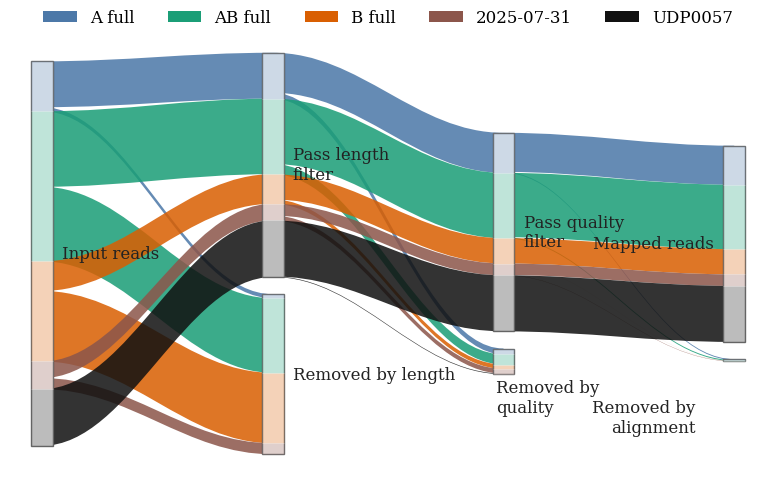

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P1 - Read retention across filtering stages by dataset.svg')

In [65]:
PLOT_3_1_ORDER = ["A_full", "B_full", "AB_full", "2025_07_31", "UDP0057"]
plot_3_1_df = data_df[data_df["display_name"].isin(PLOT_3_1_ORDER)].copy()
dataset_sankey_colors = {
    "A_full": "#4c78a8",
    "AB_full": "#1b9e77",
    "B_full": "#d95f02",
    "2025_07_31": "#8c564b",
    "UDP0057": "#111111",
}
dataset_sankey_labels = {
    "A_full": "A full",
    "AB_full": "AB full",
    "B_full": "B full",
    "2025_07_31": "2025-07-31",
    "UDP0057": "UDP0057",
}
dataset_group_order = [name for name in DATASET_ORDER if name in plot_3_1_df["display_name"].tolist()]
dataset_links = []

for _, row in plot_3_1_df.sort_values("sort_order").iterrows():
    name = row["display_name"]
    pre = int(row["pre_length_filter_reads"])
    post_length = int(row["post_length_filter_reads"])
    post_quality = int(row["post_quality_filter_reads"])
    post_alignment = int(row["post_alignment_filter_reads"])
    dataset_links.extend(
        [
            {"source": "Input", "target": "Length pass", "group": name, "value": post_length},
            {"source": "Input", "target": "Removed at length", "group": name, "value": pre - post_length},
            {"source": "Length pass", "target": "Quality pass", "group": name, "value": post_quality},
            {"source": "Length pass", "target": "Removed at quality", "group": name, "value": post_length - post_quality},
            {"source": "Quality pass", "target": "Alignment pass", "group": name, "value": post_alignment},
            {"source": "Quality pass", "target": "Removed at alignment", "group": name, "value": post_quality - post_alignment},
        ]
    )

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_segmented_sankey(
    ax,
    columns=[
        ["Input"],
        ["Length pass", "Removed at length"],
        ["Quality pass", "Removed at quality"],
        ["Alignment pass", "Removed at alignment"],
    ],
    column_x=[0.05, 0.35, 0.65, 0.95],
    links=dataset_links,
    group_order=dataset_group_order,
    group_colors=dataset_sankey_colors,
    node_labels={
        "Input": "Input reads",
        "Length pass": "Pass length\nfilter",
        "Removed at length": "Removed by length",
        "Quality pass": "Pass quality\nfilter",
        "Removed at quality": "Removed by\nquality",
        "Alignment pass": "Mapped reads",
        "Removed at alignment": "Removed by\nalignment",
    },
    label_positions={
        "Removed at quality": {"x": 0.64, "y": 0.205, "ha": "left", "va": "center"},
        "Removed at alignment": {"x": 0.90, "y": 0.165, "ha": "right", "va": "center"},
    },
)
dataset_handles = [
    mpl.patches.Patch(facecolor=dataset_sankey_colors[name], edgecolor="none", label=dataset_sankey_labels[name])
    for name in dataset_group_order
]
ax.legend(
    dataset_handles,
    [handle.get_label() for handle in dataset_handles],
    frameon=False,
    bbox_to_anchor=(0.5, 0.95),
    loc="lower center",
    borderaxespad=0.0,
    ncol=5,
)
finalize_panel(fig, "P1 - Read retention across filtering stages by dataset")


## P2 - Distribution of per-read Mean-Q scores

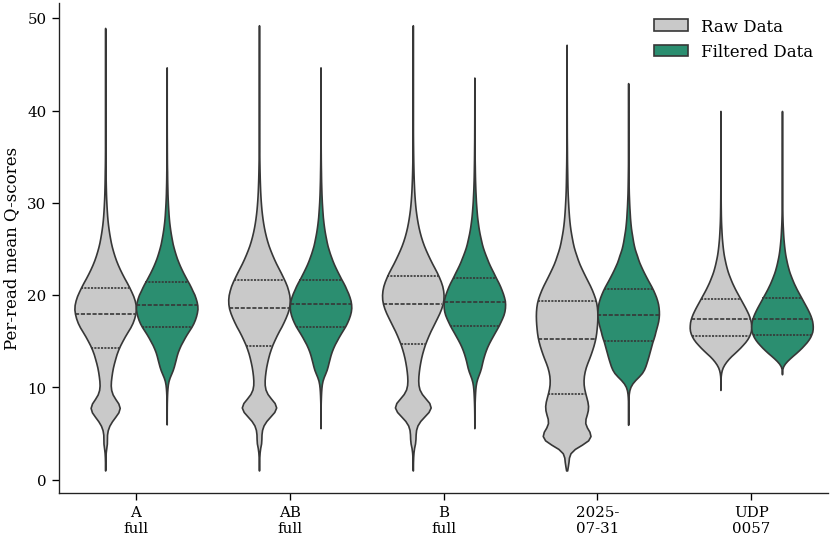

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P2 - Distribution of per-read mean Q-scores.svg')

In [27]:
PLOT_3_1_ORDER = ["A_full", "B_full", "AB_full", "2025_07_31", "UDP0057"]
plot_3_1_df = data_df[data_df["display_name"].isin(PLOT_3_1_ORDER)].copy()
fastq_df = load_fastq_distribution(plot_3_1_df, sys.maxsize)
violin_order = [name for name in DATASET_ORDER if name in fastq_df["dataset"].unique()]
dataset_tick_labels = {
    "A_full": "A\nfull",
    "A_filtered": "A\nfiltered",
    "AB_full": "AB\nfull",
    "AB_filtered": "AB\nfiltered",
    "B_full": "B\nfull",
    "B_filtered": "B\nfiltered",
    "2025_07_31": "2025-\n07-31",
    "UDP0057": "UDP\n0057",
}

fig, ax = plt.subplots(figsize=(8.27, 5.3))
sns.violinplot(
    data=fastq_df,
    x="dataset",
    y="mean_q",
    hue="filter",
    hue_order=["Raw Data", "Filtered Data"],
    order=violin_order,
    split=False,
    dodge=True,
    inner="quart",
    linewidth=1.0,
    palette=["#c9c9c9", "#1b9e77"],
    ax=ax,
    density_norm="width",
    cut=0,
)
ax.set_xlabel("")
ax.set_ylabel("Per-read mean Q-scores")
ax.set_xticks(np.arange(len(violin_order)))
ax.set_xticklabels([dataset_tick_labels.get(name, name) for name in violin_order], rotation=0, ha="center")
stage_handles, stage_labels = ax.get_legend_handles_labels()
if ax.legend_ is not None:
    ax.legend_.remove()
ax.legend(stage_handles, stage_labels, frameon=False, loc="upper right", title="", ncol=1)
finalize_panel(fig, "P2 - Distribution of per-read mean Q-scores")


## P3 - Read retention across filtering stages by model


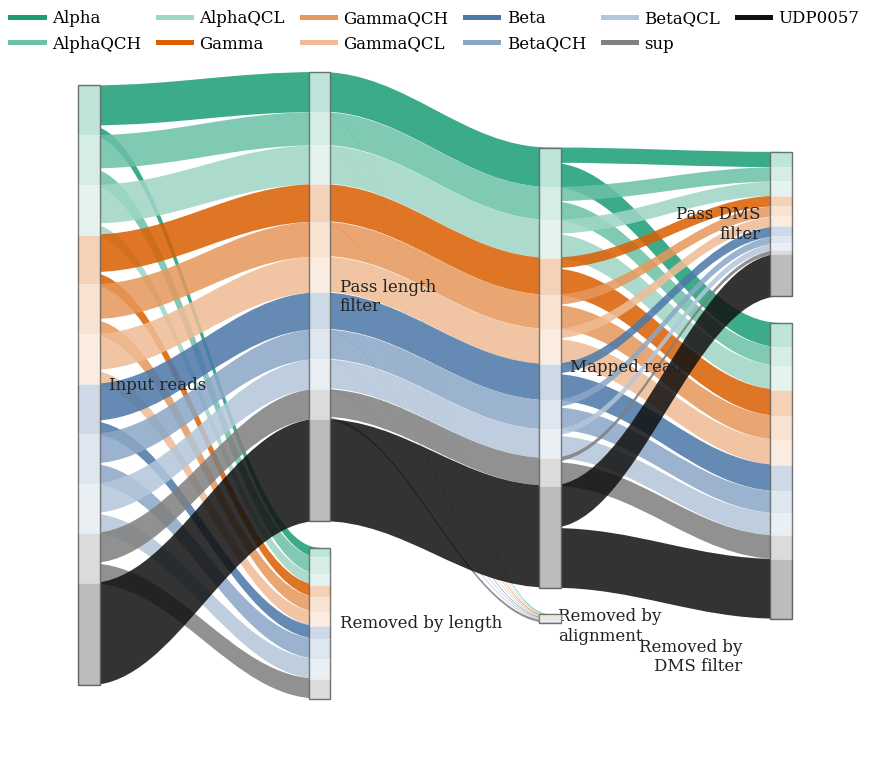

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P3 - Read retention across filtering stages by model.svg')

In [7]:
plot_3_2_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy()
plot_3_2_order = [name for name in DISPLAY_ORDER if name in plot_3_2_df["display_name"].tolist()]
plot_3_2_colors = {}
for _, row in plot_3_2_df.iterrows():
    color = family_color(row["family"])
    if row["variant"] == "QCH":
        color = mpl.colors.to_hex(lighten_color(color, 0.35))
    elif row["variant"] == "QCL":
        color = mpl.colors.to_hex(lighten_color(color, 0.58))
    plot_3_2_colors[row["display_name"]] = color

model_links = []
for _, row in plot_3_2_df.sort_values("sort_order").iterrows():
    name = row["display_name"]
    pre = int(row["pre_length_filter_reads"])
    post_length = int(row["post_length_filter_reads"])
    post_alignment = int(row["post_alignment_filter_reads"])
    post_dms = int(row["post_dms_filter_reads"])
    model_links.extend(
        [
            {"source": "Input", "target": "Length pass", "group": name, "value": post_length},
            {"source": "Input", "target": "Removed at length", "group": name, "value": pre - post_length},
            {"source": "Length pass", "target": "Alignment pass", "group": name, "value": post_alignment},
            {"source": "Length pass", "target": "Removed at alignment", "group": name, "value": post_length - post_alignment},
            {"source": "Alignment pass", "target": "DMS pass", "group": name, "value": post_dms},
            {"source": "Alignment pass", "target": "Removed at DMS", "group": name, "value": post_alignment - post_dms},
        ]
    )

fig, ax = plt.subplots(figsize=(8.27, 8.27))
draw_segmented_sankey(
    ax,
    columns=[
        ["Input"],
        ["Length pass", "Removed at length"],
        ["Alignment pass", "Removed at alignment"],
        ["DMS pass", "Removed at DMS"],
    ],
    column_x=[0.05, 0.35, 0.65, 0.95],
    links=model_links,
    group_order=plot_3_2_order,
    group_colors=plot_3_2_colors,
    node_labels={
        "Input": "Input reads",
        "Length pass": "Pass length\nfilter",
        "Removed at length": "Removed by length",
        "Alignment pass": "Mapped reads",
        "Removed at alignment": "Removed by\nalignment",
        "DMS pass": "Pass DMS\nfilter",
        "Removed at DMS": "Removed by\nDMS filter",
    },
    label_positions={
        "Removed at alignment": {"x": 0.66, "y": 0.185, "ha": "left", "va": "center"},
        "Removed at DMS": {"x": 0.90, "y": 0.145, "ha": "right", "va": "center"},
    },
)
panel_a_handles = [Line2D([0], [0], color=plot_3_2_colors[name], lw=3, label=name) for name in plot_3_2_order]
ax.legend(
    handles=panel_a_handles,
    frameon=False,
    ncol=6,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    borderaxespad=0.0,
    columnspacing=1.0,
    handletextpad=0.5,
)
finalize_panel(fig, "P3 - Read retention across filtering stages by model")


## P4 - Primary error rate vs DMS pass rate

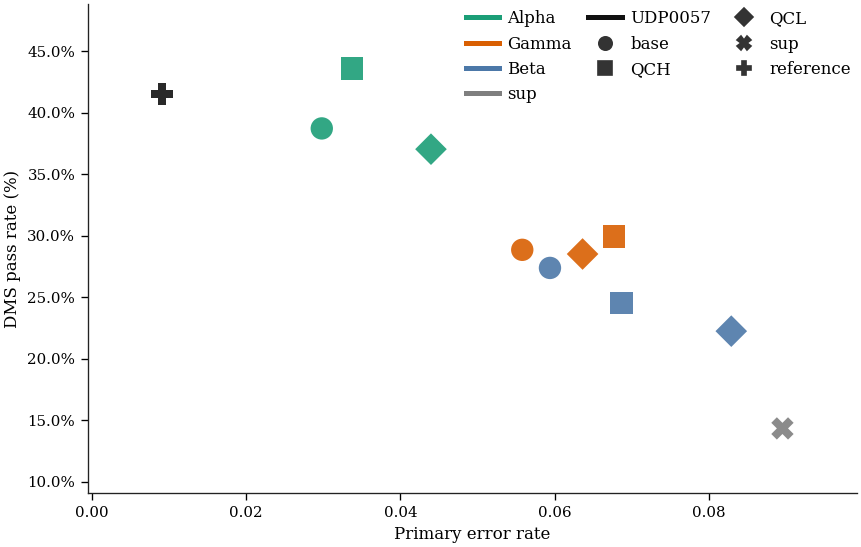

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P4 - Primary error rate vs DMS pass rate.svg')

In [26]:
plot_3_2_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy()
family_handles, variant_handles = build_legend_handles(include_reference=True)

fig, ax = plt.subplots(figsize=(8.27, 5.3))
for _, row in plot_3_2_df.iterrows():
    ax.scatter(
        row["primary_overall_error_rate"],
        row["pass_rate"],
        s=MODEL_MARKER_SIZE,
        color=family_color(row["family"]),
        marker=VARIANT_MARKERS[row["variant"]],
        alpha=0.90,
        edgecolors="none",
    )
ax.set_xlabel("Primary error rate")
ax.set_ylabel("DMS pass rate (%)")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.margins(x=0.12, y=0.18)
fig.legend(
    handles=family_handles + variant_handles,
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.7, 0.88),
    borderaxespad=0.0,
    columnspacing=1.0,
    handletextpad=0.5,
)
finalize_panel(fig, "P4 - Primary error rate vs DMS pass rate")


## P5 - Mean per-read Q-score vs weighted Jaccard similarity @1

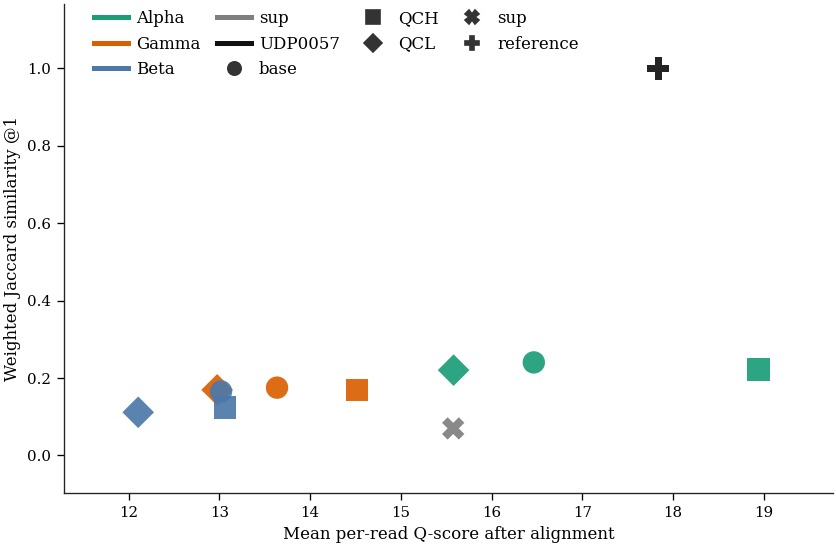

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P5 - Mean per-read Q-score vs weighted Jaccard similarity @1.svg')

In [20]:
plot_3_2_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy()
model_qscore_df = build_model_mean_q_summary(plot_3_2_df, filter="post_alignment_filter", sample_size=sys.maxsize)
qscore_scatter_df = model_qscore_df.merge(
    plot_3_2_df[["display_name", "weighted_jaccard_1"]],
    on="display_name",
    how="left",
)
family_handles, variant_handles = build_legend_handles(include_reference=True)

fig, ax = plt.subplots(figsize=(8.27, 5.3))
for _, row in qscore_scatter_df.iterrows():
    ax.scatter(
        row["mean_per_read_q"],
        row["weighted_jaccard_1"],
        s=MODEL_MARKER_SIZE,
        color=family_color(row["family"]),
        marker=VARIANT_MARKERS[row["variant"]],
        alpha=0.92,
        edgecolors="none",
    )
ax.set_xlabel("Mean per-read Q-score after alignment")
ax.set_ylabel("Weighted Jaccard similarity @1")
ax.margins(x=0.12, y=0.18)
fig.legend(
    handles=family_handles + variant_handles,
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.4, 0.88),
    borderaxespad=0.0,
    columnspacing=1.0,
    handletextpad=0.5,
)
finalize_panel(fig, "P5 - Mean per-read Q-score vs weighted Jaccard similarity @1")

## P6 - Normalised multi-metric performance comparison

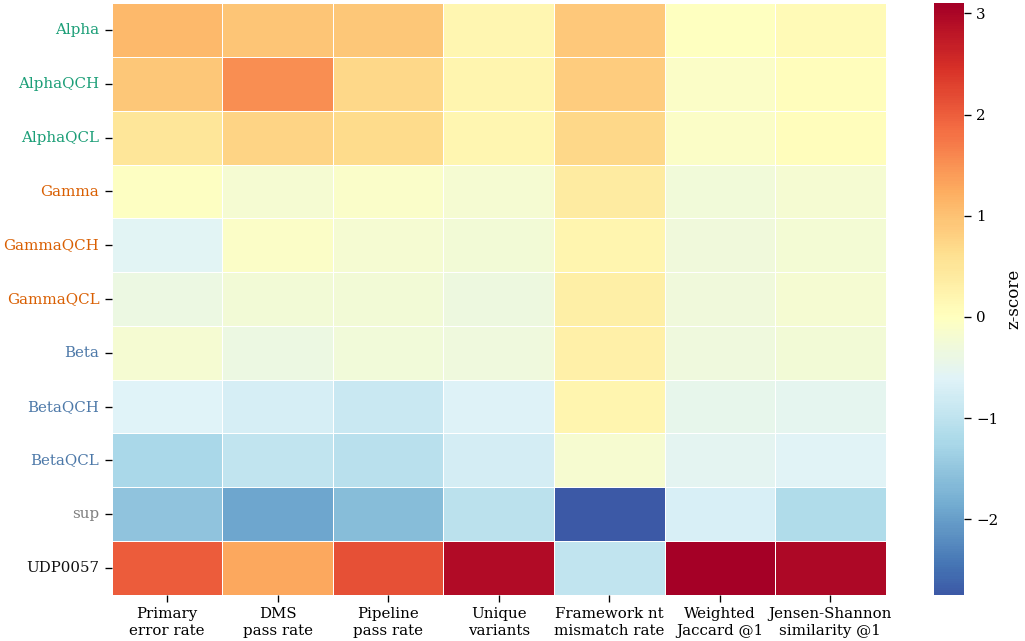

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P6 - Normalised multi-metric performance comparison.svg')

In [50]:
plot_3_2_metrics = [
    ("primary_overall_error_rate", "Primary error", False),
    ("pass_rate", "DMS pass rate", True),
    ("pipeline_pass_rate", "Pipeline pass rate", True),
    ("unique_variants", "Unique variants", True),
    ("avg_framework_nucleotide_mismatches_per_read", "Framework nt mismatch", False),
    ("weighted_jaccard_1", "Weighted Jaccard @1", True),
    ("jensen_shannon_similarity_1", "Jensen-Shannon similarity @1", True),
]
plot_3_2_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy()
plot_3_2_order = [name for name in DISPLAY_ORDER if name in plot_3_2_df["display_name"].tolist()]
heatmap_df = (
    zscore_metrics(plot_3_2_df.set_index("display_name").loc[plot_3_2_order], plot_3_2_metrics)
    .loc[plot_3_2_order]
)

fig, ax = plt.subplots(figsize=(10.4, 6.4))
sns.heatmap(
    heatmap_df,
    cmap="RdYlBu_r",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "z-score"},
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(
    [
        "Primary\nerror rate",
        "DMS\npass rate",
        "Pipeline\npass rate",
        "Unique\nvariants",
        "Framework nt\nmismatch rate",
        "Weighted\nJaccard @1",
        "Jensen-Shannon\nsimilarity @1",
    ],
    rotation=0,
    ha="center",
)
color_model_ticklabels(ax, axis="y")
finalize_panel(fig, "P6 - Normalised multi-metric performance comparison")


## P7 - Validation loss vs weighted Jaccard similarity @1

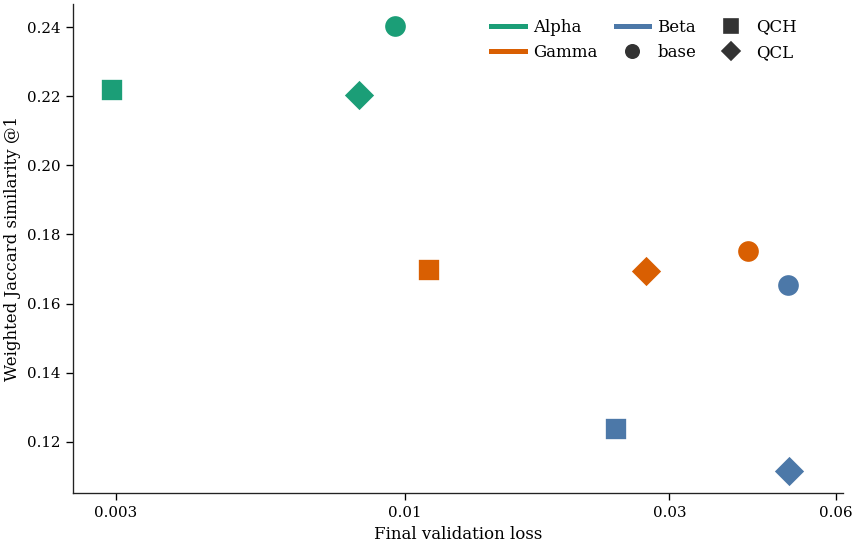

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P7 - Validation loss vs weighted Jaccard similarity @1.svg')

In [31]:
plot_3_3_df = model_summary_df[model_summary_df["display_name"].isin([name for name in MODEL_ONLY_ORDER if name != "sup"])].copy()
x_min = plot_3_3_df["validation_loss"].min()
x_max = plot_3_3_df["validation_loss"].max()
validation_ticks = [0.003, 0.01, 0.03, 0.06]
plot_3_3_families = [family for family in ["Alpha", "Gamma", "Beta"] if family in plot_3_3_df["family"].unique()]
plot_3_3_variants = [variant for variant in ["base", "QCH", "QCL"] if variant in plot_3_3_df["variant"].unique()]
plot_3_3_family_handles = [Line2D([0], [0], color=family_color(family), lw=3, label=family) for family in plot_3_3_families]
plot_3_3_variant_handles = [
    Line2D([0], [0], color="#333333", marker=VARIANT_MARKERS[variant], lw=0, ms=8, label=variant)
    for variant in plot_3_3_variants
]
fig, ax = plt.subplots(figsize=(8.27, 5.3))
for _, row in plot_3_3_df.iterrows():
    ax.scatter(
        row["validation_loss"],
        row["weighted_jaccard_1"],
        s=MODEL_MARKER_SIZE,
        color=family_color(row["family"]),
        marker=VARIANT_MARKERS[row["variant"]],
        edgecolor="white",
        linewidth=1.0,
    )
ax.set_xscale("log")
ax.set_xlim(x_min * 0.85, x_max * 1.25)
ax.set_xticks(validation_ticks)
ax.xaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda value, pos: f"{value:.3f}" if value < 0.01 else f"{value:.2f}".rstrip("0").rstrip("."))
)
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.set_xlabel("Final validation loss")
ax.set_ylabel("Weighted Jaccard similarity @1")
if "weighted_jaccard_1" == "pass_rate":
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
fig.legend(
    handles=plot_3_3_family_handles + plot_3_3_variant_handles,
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.70, 0.88),
    columnspacing=1.1,
    handletextpad=0.5,
)
finalize_panel(fig, "P7 - Validation loss vs weighted Jaccard similarity @1")


## P8 - Validation loss vs DMS pass rate

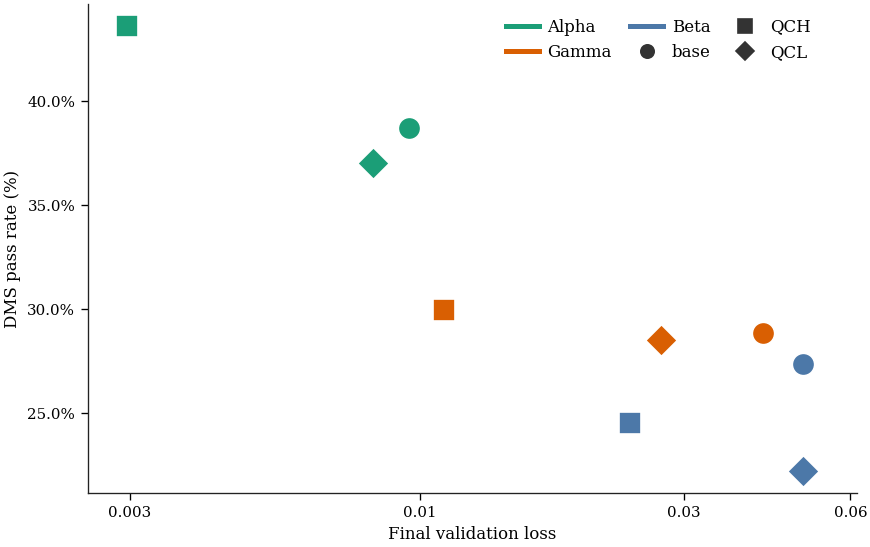

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P8 - Validation loss vs DMS pass rate.svg')

In [30]:
plot_3_3_df = model_summary_df[model_summary_df["display_name"].isin([name for name in MODEL_ONLY_ORDER if name != "sup"])].copy()
x_min = plot_3_3_df["validation_loss"].min()
x_max = plot_3_3_df["validation_loss"].max()
validation_ticks = [0.003, 0.01, 0.03, 0.06]
plot_3_3_families = [family for family in ["Alpha", "Gamma", "Beta"] if family in plot_3_3_df["family"].unique()]
plot_3_3_variants = [variant for variant in ["base", "QCH", "QCL"] if variant in plot_3_3_df["variant"].unique()]
plot_3_3_family_handles = [Line2D([0], [0], color=family_color(family), lw=3, label=family) for family in plot_3_3_families]
plot_3_3_variant_handles = [
    Line2D([0], [0], color="#333333", marker=VARIANT_MARKERS[variant], lw=0, ms=8, label=variant)
    for variant in plot_3_3_variants
]

fig, ax = plt.subplots(figsize=(8.27, 5.3))
for _, row in plot_3_3_df.iterrows():
    ax.scatter(
        row["validation_loss"],
        row["pass_rate"],
        s=MODEL_MARKER_SIZE,
        color=family_color(row["family"]),
        marker=VARIANT_MARKERS[row["variant"]],
        edgecolor="white",
        linewidth=1.0,
    )
ax.set_xscale("log")
ax.set_xlim(x_min * 0.85, x_max * 1.25)
ax.set_xticks(validation_ticks)
ax.xaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda value, pos: f"{value:.3f}" if value < 0.01 else f"{value:.2f}".rstrip("0").rstrip("."))
)
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.set_xlabel("Final validation loss")
ax.set_ylabel("DMS pass rate (%)")
if "pass_rate" == "pass_rate":
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
fig.legend(
    handles=plot_3_3_family_handles + plot_3_3_variant_handles,
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.7, 0.88),
    columnspacing=1.1,
    handletextpad=0.5,
)
finalize_panel(fig, "P8 - Validation loss vs DMS pass rate")


## P9 - Error rate before and after polishing

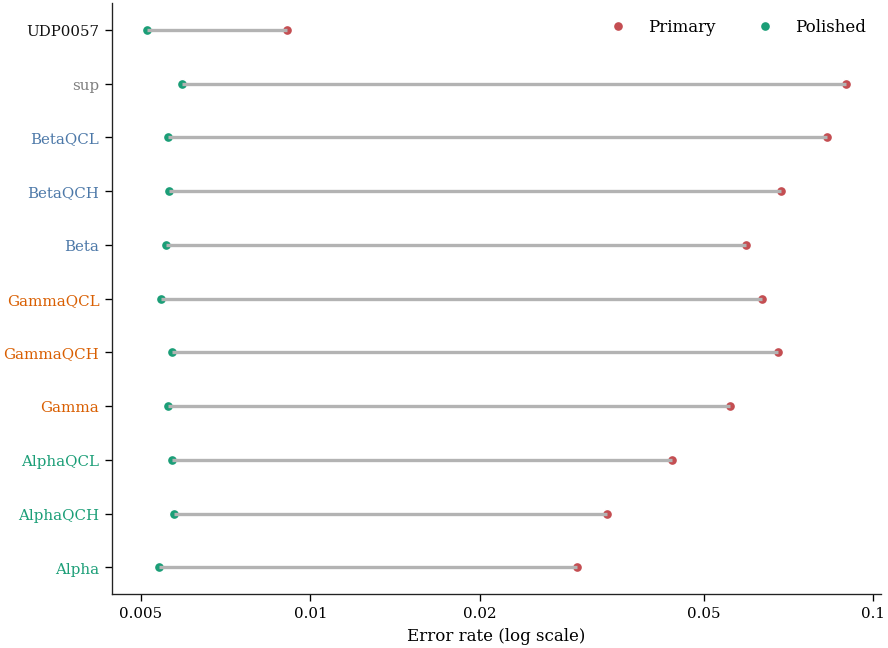

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P9 - Error rate before and after polishing.svg')

In [32]:
plot_3_4_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy().sort_values("sort_order")
y_pos = np.arange(len(plot_3_4_df))

fig, ax = plt.subplots(figsize=(8.27, 6.4))
ax.hlines(y_pos, plot_3_4_df["polished_overall_error_rate"], plot_3_4_df["primary_overall_error_rate"], color="#b3b3b3", lw=2)
ax.scatter(plot_3_4_df["primary_overall_error_rate"], y_pos, color="#c44e52", edgecolor="white", linewidth=0.8, label="Primary")
ax.scatter(plot_3_4_df["polished_overall_error_rate"], y_pos, color="#1b9e77", edgecolor="white", linewidth=0.8, label="Polished")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_3_4_df["display_name"])
color_model_ticklabels(ax, axis="y")
ax.set_xscale("log")
ax.set_xticks([0.005, 0.01, 0.02, 0.05, 0.1])
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda value, pos: f"{value:.3f}" if value < 0.01 else f"{value:.2f}".rstrip("0").rstrip(".")))
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.set_xlabel("Error rate (log scale)")
ax.legend(frameon=False, loc="upper right", ncol=2)
finalize_panel(fig, "P9 - Error rate before and after polishing")


## P10 - Composition of primary error rate by error type

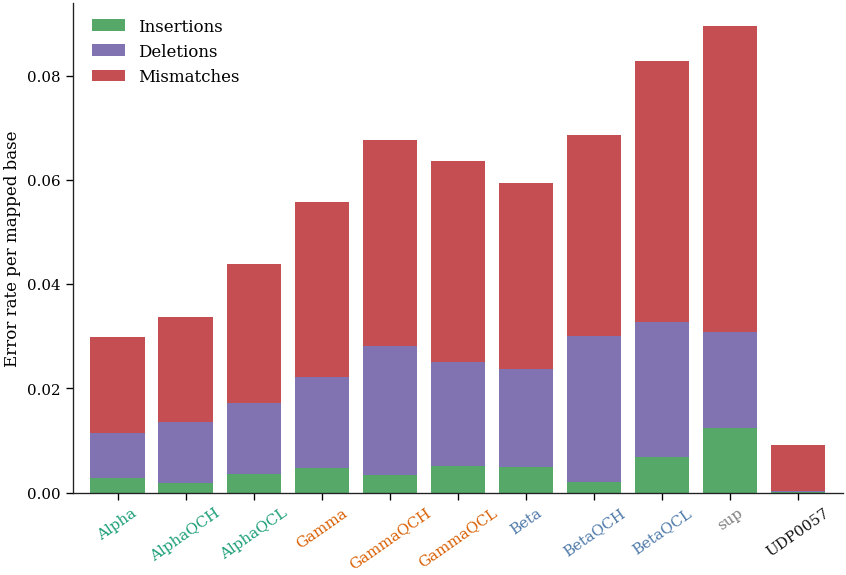

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P10 - Composition of primary error rate by error type.svg')

In [35]:
plot_3_4_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy().sort_values("sort_order")
ordered = plot_3_4_df.copy()
ordered["Insertions"] = ordered["primary_inserted_bases"] / ordered["primary_bases_mapped"]
ordered["Deletions"] = ordered["primary_deleted_bases"] / ordered["primary_bases_mapped"]
ordered["Mismatches"] = ordered["primary_mismatches"] / ordered["primary_bases_mapped"]
stacked_components = ordered.set_index("display_name")[["Insertions", "Deletions", "Mismatches"]]

fig, ax = plt.subplots(figsize=(8.27, 5.3))
stacked_components.plot(
    kind="bar",
    stacked=True,
    color=["#55a868", "#8172b2", "#c44e52"],
    ax=ax,
    width=0.8,
)
ax.set_ylabel("Error rate per mapped base")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=35)
color_model_ticklabels(ax, axis="x")
ax.legend(frameon=False, title="", loc="upper center", bbox_to_anchor=(0.12, 1), ncol=1)
finalize_panel(fig, "P10 - Composition of primary error rate by error type")


## P11 - Nucleotide mismatch burden by region

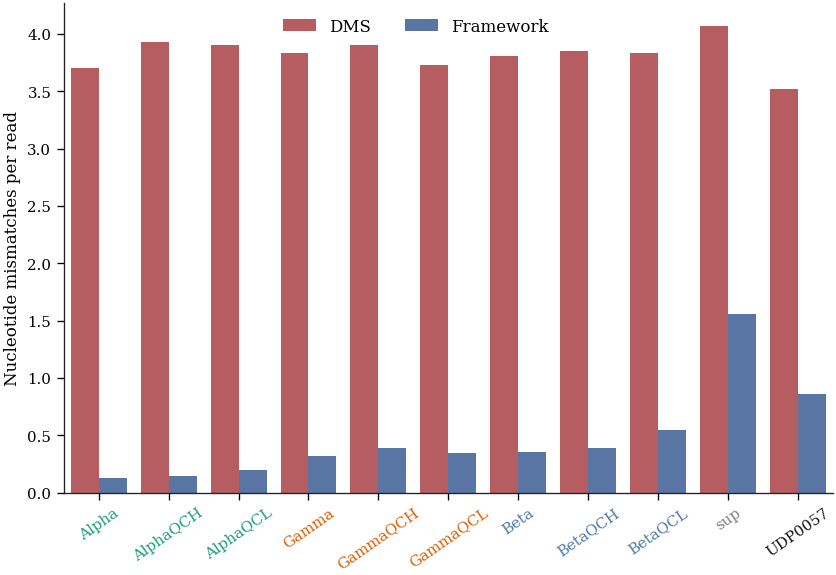

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P11 - Nucleotide mismatch burden by region.svg')

In [36]:
plot_3_4_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy().sort_values("sort_order")
burden_df = pd.concat(
    [
        plot_3_4_df[["display_name", "avg_dms_nucleotide_mismatches_per_read", "avg_framework_nucleotide_mismatches_per_read"]]
        .rename(
            columns={
                "avg_dms_nucleotide_mismatches_per_read": "DMS",
                "avg_framework_nucleotide_mismatches_per_read": "Framework",
            }
        )
        .assign(unit="Nucleotide mismatches per read"),
        plot_3_4_df[["display_name", "avg_dms_codon_mismatches_per_read", "avg_framework_codon_mismatches_per_read"]]
        .rename(
            columns={
                "avg_dms_codon_mismatches_per_read": "DMS",
                "avg_framework_codon_mismatches_per_read": "Framework",
            }
        )
        .assign(unit="Codon mismatches per read"),
    ],
    ignore_index=True,
)
burden_long = burden_df.melt(id_vars=["display_name", "unit"], value_vars=["DMS", "Framework"], var_name="region", value_name="value")
plot_3_4_order = plot_3_4_df["display_name"].tolist()

fig, ax = plt.subplots(figsize=(8.27, 5.3))
subset = burden_long[burden_long["unit"] == "Nucleotide mismatches per read"]
sns.barplot(
    data=subset,
    x="display_name",
    y="value",
    hue="region",
    palette=REGION_COLORS,
    order=plot_3_4_order,
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Nucleotide mismatches per read")
ax.tick_params(axis="x", rotation=35)
color_model_ticklabels(ax, axis="x")
ax.legend(frameon=False, title="", loc="upper right", ncol=2, bbox_to_anchor=(0.65, 1))
finalize_panel(fig, "P11 - Nucleotide mismatch burden by region")

## P12 - Codon mismatch burden by region

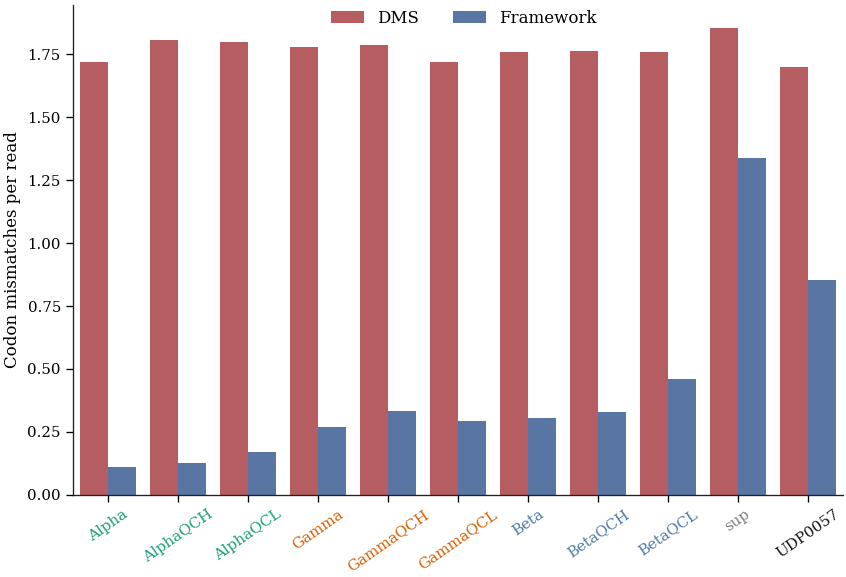

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P12 - Codon mismatch burden by region.svg')

In [44]:
plot_3_4_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy().sort_values("sort_order")
burden_df = pd.concat(
    [
        plot_3_4_df[["display_name", "avg_dms_nucleotide_mismatches_per_read", "avg_framework_nucleotide_mismatches_per_read"]]
        .rename(
            columns={
                "avg_dms_nucleotide_mismatches_per_read": "DMS",
                "avg_framework_nucleotide_mismatches_per_read": "Framework",
            }
        )
        .assign(unit="Nucleotide mismatches per read"),
        plot_3_4_df[["display_name", "avg_dms_codon_mismatches_per_read", "avg_framework_codon_mismatches_per_read"]]
        .rename(
            columns={
                "avg_dms_codon_mismatches_per_read": "DMS",
                "avg_framework_codon_mismatches_per_read": "Framework",
            }
        )
        .assign(unit="Codon mismatches per read"),
    ],
    ignore_index=True,
)
burden_long = burden_df.melt(id_vars=["display_name", "unit"], value_vars=["DMS", "Framework"], var_name="region", value_name="value")
plot_3_4_order = plot_3_4_df["display_name"].tolist()
fig, ax = plt.subplots(figsize=(8.27, 5.3))
subset = burden_long[burden_long["unit"] == "Codon mismatches per read"]
sns.barplot(
    data=subset,
    x="display_name",
    y="value",
    hue="region",
    palette=REGION_COLORS,
    order=plot_3_4_order,
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Codon mismatches per read")
ax.tick_params(axis="x", rotation=35)
color_model_ticklabels(ax, axis="x")
ax.legend(frameon=False, title="", loc="upper right", ncol=2, bbox_to_anchor=(0.7, 1.02))
finalize_panel(fig, "P12 - Codon mismatch burden by region")

## P13 - DMS Filter Failure Composition

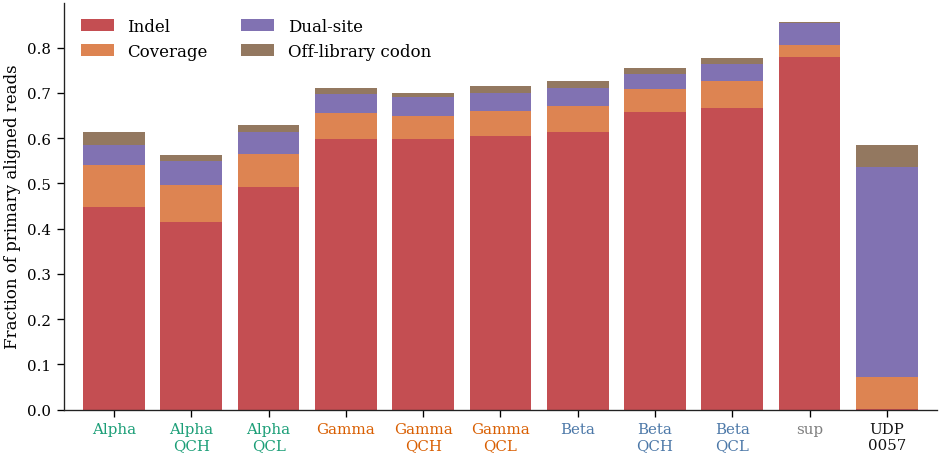

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P13 - DMS-filter failure composition.svg')

In [57]:
plot_3_5_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy().sort_values("sort_order")
compact_model_labels = [format_model_label(label) for label in plot_3_5_df["display_name"]]
failure_modes = plot_3_5_df.set_index("display_name")[
    ["failed_indel", "failed_coverage", "failed_dual_site", "failed_mut_codon_library"]
].div(plot_3_5_df.set_index("display_name")["post_alignment_filter_reads"], axis=0)
failure_modes.columns = ["Indel", "Coverage", "Dual-site", "Off-library codon"]

fig, ax = plt.subplots(figsize=(8.27, 5.3))
failure_modes.plot(
    kind="bar",
    stacked=True,
    color=["#c44e52", "#dd8452", "#8172b2", "#937860"],
    ax=ax,
    width=0.8,
)
ax.set_ylabel("Fraction of primary aligned reads")
ax.set_xlabel("")
ax.set_xticklabels(compact_model_labels, rotation=0)
color_model_ticklabels(ax, axis="x")
ax.legend(frameon=False, title="", loc="upper center", bbox_to_anchor=(0.22, 1), ncol=2)
fig.subplots_adjust(top=0.82, bottom=0.18, left=0.10, right=0.98)
finalize_panel(fig, "P13 - DMS-filter failure composition")

## P14 - Codon-mutation spectrum of DMS-pass reads

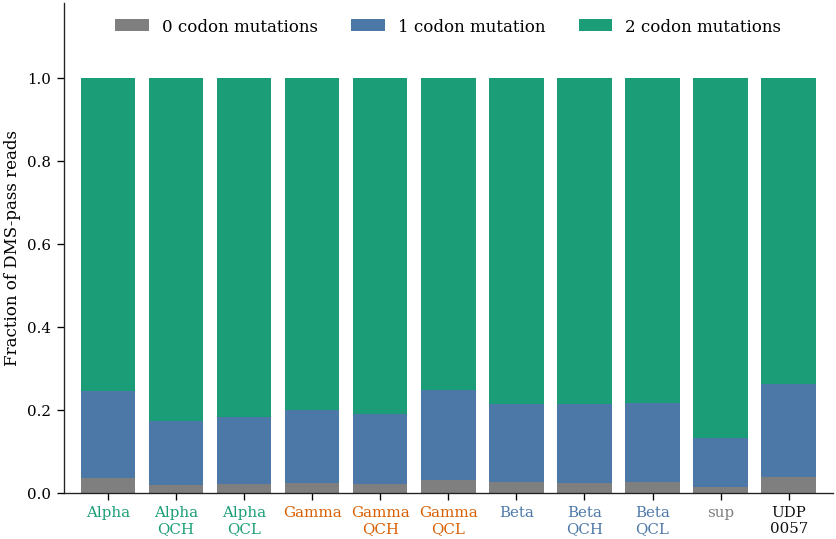

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P14 - Codon-mutation spectrum of DMS-pass reads.svg')

In [79]:
plot_3_5_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy().sort_values("sort_order")
compact_model_labels = [format_model_label(label) for label in plot_3_5_df["display_name"]]
pass_spectrum = plot_3_5_df.set_index("display_name")[
    ["pass_reads_0_codon_mutations", "pass_reads_1_codon_mutations", "pass_reads_2_codon_mutations"]
].div(plot_3_5_df.set_index("display_name")["post_dms_filter_reads"], axis=0)
pass_spectrum.columns = ["0 codon mutations", "1 codon mutation", "2 codon mutations"]
fig, ax = plt.subplots(figsize=(8.27, 5.3))
pass_spectrum.plot(
    kind="bar",
    stacked=True,
    color=["#7f7f7f", "#4c78a8", "#1b9e77"],
    ax=ax,
    width=0.8,
)
ax.set_ylim(0.0, 1.18)
ax.set_ylabel("Fraction of DMS-pass reads")
ax.set_xlabel("")
ax.set_xticklabels(compact_model_labels, rotation=0)
color_model_ticklabels(ax, axis="x")
ax.legend(frameon=False, title="", loc="upper center", bbox_to_anchor=(0.5, 1), ncol=3)
finalize_panel(fig, "P14 - Codon-mutation spectrum of DMS-pass reads")


## P15 - Framework mismatch rate vs exact overlap mass @1

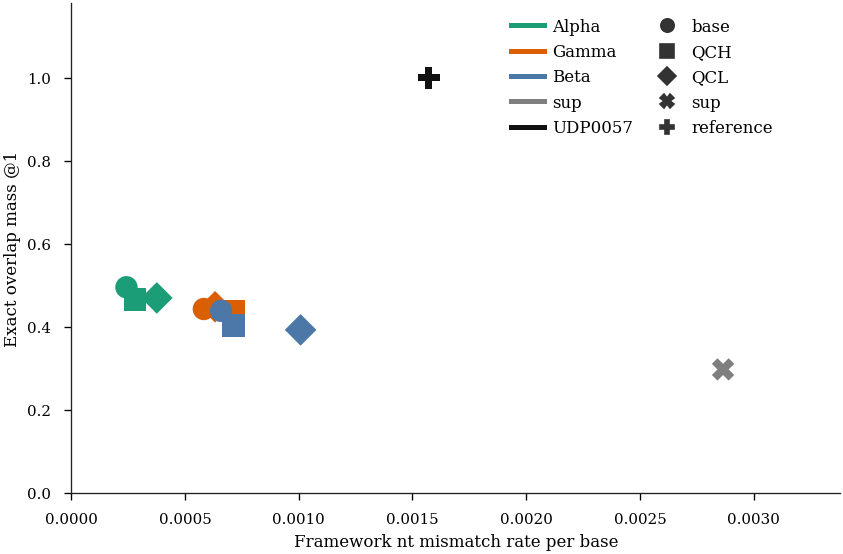

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P15 - Framework mismatch rate vs exact overlap mass @1.svg')

In [76]:
plot_3_5_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy().sort_values("sort_order")
family_handles, variant_handles = build_legend_handles(include_reference=True)

fig, ax = plt.subplots(figsize=(8.27, 5.3))
for _, row in plot_3_5_df.iterrows():
    ax.scatter(
        row["framework_nt_mismatch_rate_per_base"],
        row["exact_overlap_mass_1"],
        s=MODEL_MARKER_SIZE,
        color=family_color(row["family"]),
        marker=VARIANT_MARKERS[row["variant"]],
        clip_on=False,
        edgecolors="none",
    )
ax.set_xlabel("Framework nt mismatch rate per base")
ax.set_ylabel("Exact overlap mass @1")
ax.set_xlim(0, plot_3_5_df["framework_nt_mismatch_rate_per_base"].max() * 1.18)
ax.set_ylim(0.0, 1.18)
ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.4f"))
ax.tick_params(axis="x", pad=8)
ax.tick_params(axis="y", pad=8)
fig.legend(
    handles=family_handles + variant_handles,
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.7, 0.88),
    columnspacing=1.0,
    handletextpad=0.5,
)
finalize_panel(fig, "P15 - Framework mismatch rate vs exact overlap mass @1")


## P16 - Framework codon mismatch rate vs Jensen-Shannon similarity @1

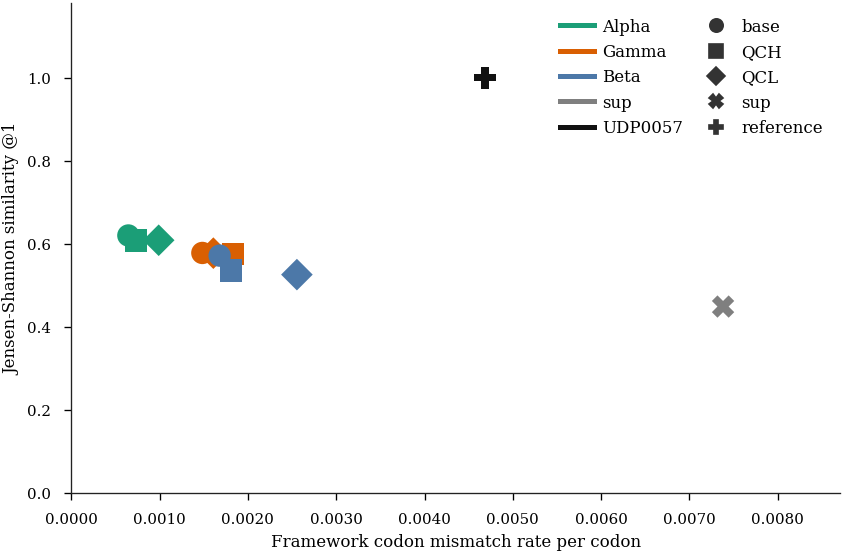

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P16 - Framework codon mismatch rate vs Jensen-Shannon similarity @1.svg')

In [88]:
plot_3_5_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy().sort_values("sort_order")
family_handles, variant_handles = build_legend_handles(include_reference=True)

fig, ax = plt.subplots(figsize=(8.27, 5.3))
for _, row in plot_3_5_df.iterrows():
    ax.scatter(
        row["framework_codon_mismatch_rate_per_codon"],
        row["jensen_shannon_similarity_1"],
        s=MODEL_MARKER_SIZE,
        color=family_color(row["family"]),
        marker=VARIANT_MARKERS[row["variant"]],
        clip_on=False,
        edgecolors="none",
    )
ax.set_xlabel("Framework codon mismatch rate per codon")
ax.set_ylabel("Jensen-Shannon similarity @1")
ax.set_xlim(0, plot_3_5_df["framework_codon_mismatch_rate_per_codon"].max() * 1.18)
ax.set_ylim(0.0, 1.18)
ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.4f"))
ax.tick_params(axis="x", pad=8)
ax.tick_params(axis="y", pad=8)
fig.legend(
    handles=family_handles + variant_handles,
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.75, 0.88),
    columnspacing=1.0,
    handletextpad=0.5,
)
finalize_panel(fig, "P16 - Framework codon mismatch rate vs Jensen-Shannon similarity @1")


## P17 - Per-position mismatch-rate profiles before and after polishing

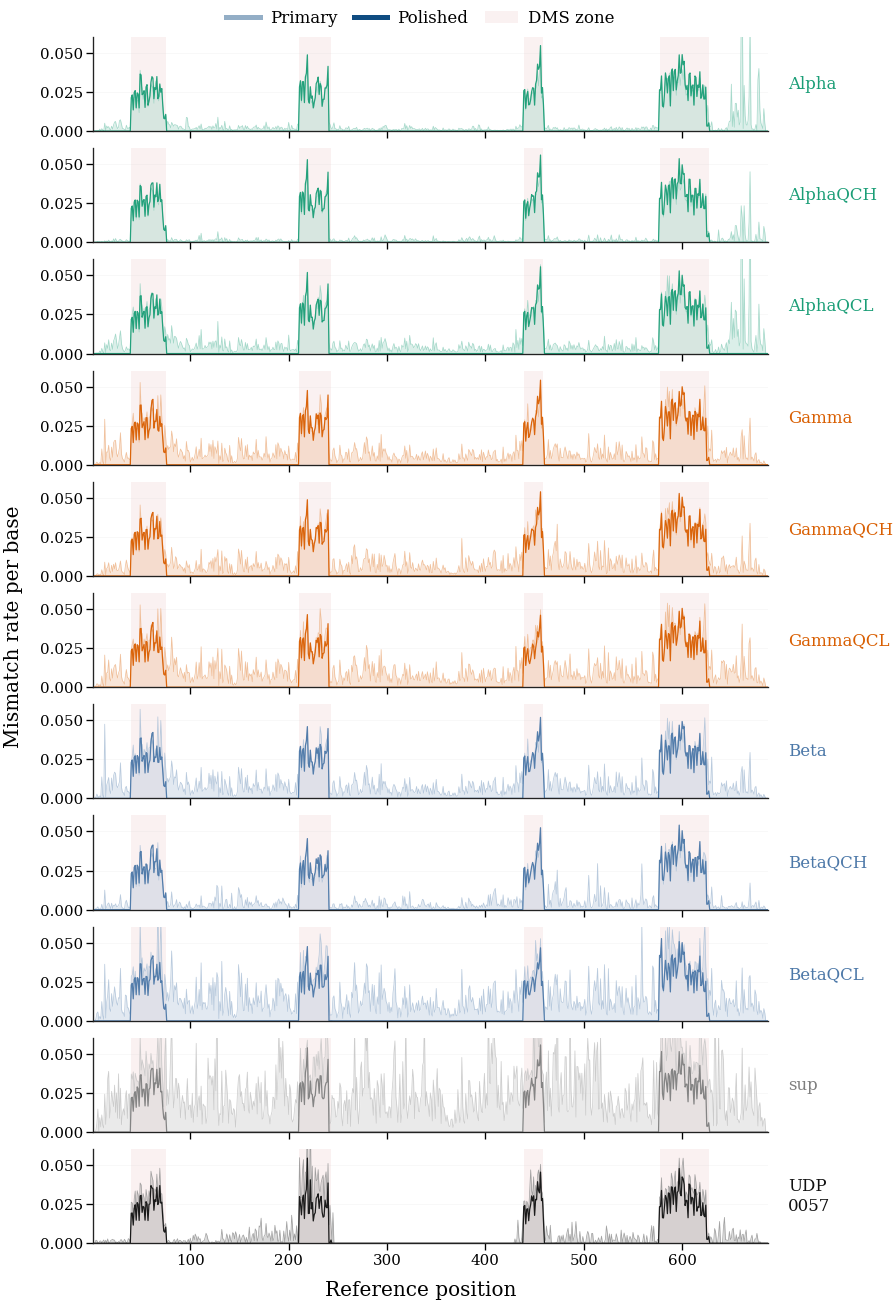

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P17 - Per-position mismatch-rate profiles before and after polishing.svg')

In [103]:
mutation_density_models = DISPLAY_ORDER
summary_lookup = summary_df.set_index("display_name")
density_lookup = {
    (model_name, stage): compute_mutation_density(model_name, stage=stage, force=False, threads=32)
    for model_name in mutation_density_models
    for stage in ["primary", "polished"]
}
all_density_rates = pd.concat(
    [df[["mismatch_rate"]] for df in density_lookup.values() if not df.empty],
    ignore_index=True,
)
density_ymax = all_density_rates["mismatch_rate"].quantile(0.995) * 1.08 if not all_density_rates.empty else 1.0

fig, axes = plt.subplots(
    len(mutation_density_models),
    1,
    figsize=(8.27, 11.69),
    gridspec_kw={"hspace": 0.18},
    sharex=True,
    sharey=True,
)
if len(mutation_density_models) == 1:
    axes = [axes]
comparison_handles = [
    Line2D([0], [0], color=lighten_color("#0f4c81", 0.55), lw=3.0, label="Primary"),
    Line2D([0], [0], color="#0f4c81", lw=3.0, label="Polished"),
    mpl.patches.Patch(facecolor=REGION_COLORS["DMS"], alpha=0.08, label="DMS zone"),
]

for row_idx, model_name in enumerate(mutation_density_models):
    model_row = summary_lookup.loc[model_name]
    model_color = family_color(model_row["family"])
    primary_color = lighten_color(model_color, 0.55)
    ax_density = axes[row_idx]

    primary_df = density_lookup[(model_name, "primary")]
    polished_df = density_lookup[(model_name, "polished")]
    add_dms_shading(ax_density, alpha=0.08)
    ax_density.fill_between(
        primary_df["position"],
        primary_df["mismatch_rate"],
        color=primary_color,
        alpha=0.35,
        linewidth=0,
        rasterized=True,
    )
    ax_density.plot(
        primary_df["position"],
        primary_df["mismatch_rate"],
        color=primary_color,
        lw=0.45,
        alpha=0.85,
        rasterized=True,
    )
    ax_density.plot(
        polished_df["position"],
        polished_df["mismatch_rate"],
        color=model_color,
        lw=0.75,
        alpha=0.95,
        rasterized=True,
    )
    ax_density.set_xlim(1, REFERENCE_LENGTH)
    ax_density.set_ylim(0, density_ymax)
    ax_density.yaxis.set_major_locator(mpl.ticker.MaxNLocator(3))
    ax_density.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.3f"))
    ax_density.yaxis.offsetText.set_visible(False)
    ax_density.grid(True, axis="y", alpha=0.18)
    ax_density.tick_params(axis="both", pad=2)
    ax_density.text(
        1.03,
        0.5,
        "UDP\n0057" if model_name == "UDP0057" else model_name,
        transform=ax_density.transAxes,
        ha="left",
        va="center",
        color=model_color,
    )

fig.legend(
    handles=comparison_handles,
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.55, 0.95),
    columnspacing=1.0,
    handletextpad=0.6,
)
fig.supylabel("Mismatch rate per base", x=0.13)
fig.supxlabel("Reference position", x=0.55, y=0.02)
fig.subplots_adjust(top=0.92, bottom=0.06, left=0.22, right=0.90)
finalize_panel(fig, "P17 - Per-position mismatch-rate profiles before and after polishing")


## P18 - Shared mutation frequency differences across DMS positions

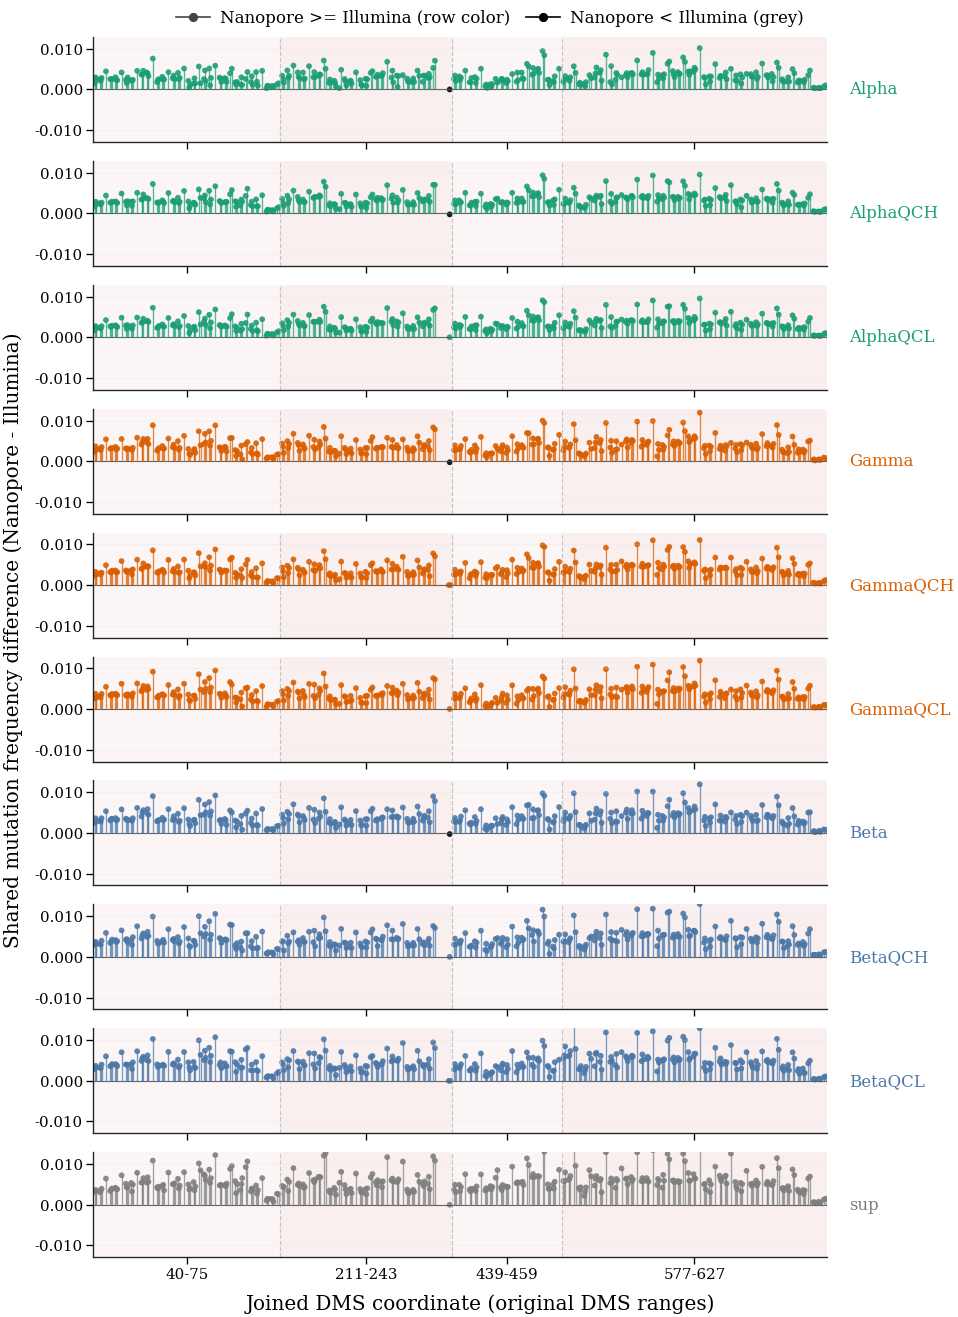

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P18 - Shared mutation frequency differences across DMS positions.svg')

In [113]:
shared_difference_models = MODEL_ONLY_ORDER
illumina_color = "#000000"
summary_lookup = summary_df.set_index("display_name")
shared_difference_lookup = {
    model_name: build_shared_mutation_difference_data(model_name, threshold=1, dms_only=True, exclude_wt=True)
    for model_name in shared_difference_models
}
all_shared_differences = pd.concat(
    [df[["abs_difference"]] for df in shared_difference_lookup.values() if not df.empty],
    ignore_index=True,
)
shared_difference_ymax = all_shared_differences["abs_difference"].quantile(0.995) * 1.08 if not all_shared_differences.empty else 1.0

fig, axes = plt.subplots(
    len(shared_difference_models),
    1,
    figsize=(8.27, 11.69),
    gridspec_kw={"hspace": 0.18},
    sharex=True,
    sharey=True,
)
if len(shared_difference_models) == 1:
    axes = [axes]
difference_handles = [
    Line2D([0], [0], color="#444444", marker="o", lw=1.0, ms=4.5, label="Nanopore >= Illumina (row color)"),
    Line2D([0], [0], color=illumina_color, marker="o", lw=1.0, ms=4.5, label="Nanopore < Illumina (grey)"),
]

for row_idx, model_name in enumerate(shared_difference_models):
    model_row = summary_lookup.loc[model_name]
    model_color = family_color(model_row["family"])
    ax = axes[row_idx]
    diff_df = shared_difference_lookup[model_name].copy()
    for seg_idx, segment in enumerate(JOINED_DMS_SEGMENTS):
        ax.axvspan(
            segment["joined_start"] - 0.5,
            segment["joined_end"] + 0.5,
            color=REGION_COLORS["DMS"],
            alpha=0.05 if seg_idx % 2 == 0 else 0.09,
            lw=0,
        )
        if seg_idx > 0:
            ax.axvline(segment["joined_start"] - 0.5, color="#bdbdbd", ls="--", lw=0.7, alpha=0.85)
    ax.axhline(0.0, color="#555555", lw=0.7, alpha=0.9)

    if not diff_df.empty:
        diff_df = diff_df.sort_values(["joined_position", "mutation_token"]).reset_index(drop=True)
        diff_df["event_rank"] = diff_df.groupby("joined_position").cumcount()
        diff_df["event_count"] = diff_df.groupby("joined_position")["mutation_token"].transform("size")
        diff_df["plot_position"] = diff_df["joined_position"]
        multi_event_mask = diff_df["event_count"] > 1
        diff_df.loc[multi_event_mask, "plot_position"] = diff_df.loc[multi_event_mask, "joined_position"] + (
            (diff_df.loc[multi_event_mask, "event_rank"] / (diff_df.loc[multi_event_mask, "event_count"] - 1)) - 0.5
        ) * 0.34
        diff_df["stem_color"] = np.where(diff_df["frequency_difference"] >= 0, model_color, illumina_color)
        for color, subset in diff_df.groupby("stem_color", sort=False):
            ax.vlines(
                subset["plot_position"],
                0.0,
                subset["frequency_difference"],
                color=color,
                lw=0.8,
                alpha=0.72,
                rasterized=True,
            )
            ax.scatter(
                subset["plot_position"],
                subset["frequency_difference"],
                color=color,
                s=12,
                alpha=0.9,
                edgecolors="none",
                rasterized=True,
            )

    ax.set_xlim(0.5, JOINED_DMS_LENGTH + 0.5)
    ax.set_ylim(-shared_difference_ymax, shared_difference_ymax)
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(3))
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.3f"))
    ax.grid(True, axis="y", alpha=0.18)
    ax.tick_params(axis="both", pad=2)
    ax.text(
        1.03,
        0.5,
        model_name,
        transform=ax.transAxes,
        ha="left",
        va="center",
        color=model_color,
    )
    if row_idx != len(shared_difference_models) - 1:
        ax.tick_params(labelbottom=False)
    else:
        ax.set_xticks([segment["joined_mid"] for segment in JOINED_DMS_SEGMENTS])
        ax.set_xticklabels([f"{segment['start']}-{segment['end']}" for segment in JOINED_DMS_SEGMENTS])

fig.legend(
    handles=difference_handles,
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.56, 0.96),
    columnspacing=1.0,
    handletextpad=0.6,
)
fig.supylabel("Shared mutation frequency difference (Nanopore - Illumina)", x=0.07)
fig.supxlabel("Joined DMS coordinate (original DMS ranges)", x=0.55, y=0.02)
fig.subplots_adjust(top=0.93, bottom=0.06, left=0.16, right=0.90)
finalize_panel(fig, "P18 - Shared mutation frequency differences across DMS positions")

## P19 - Weighted Jaccard concordance ranking @1

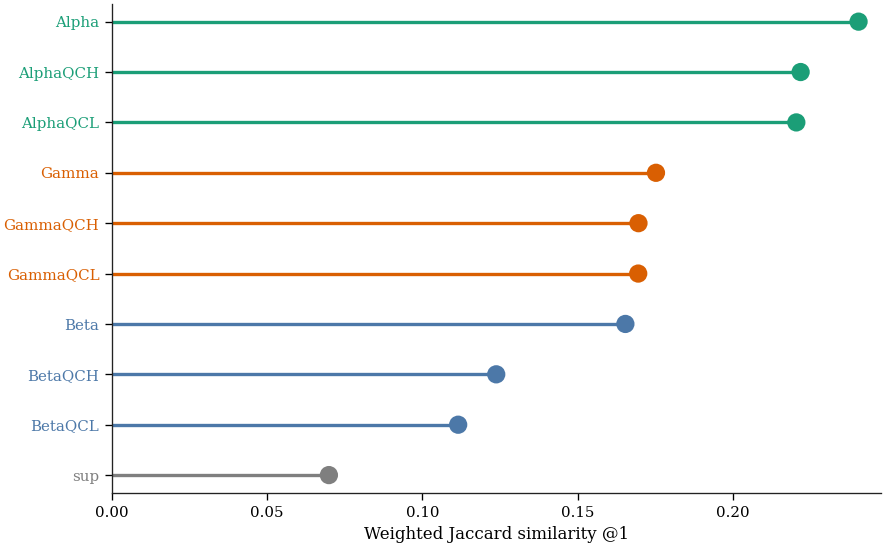

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P19 - Weighted Jaccard concordance ranking @1.svg')

In [111]:
threshold_1_rank = correlation_df[correlation_df["display_name"] != "UDP0057"].copy().sort_values("weighted_jaccard_1", ascending=True)
fig, ax = plt.subplots(figsize=(8.27, 5.3))
ax.hlines(
    threshold_1_rank["display_name"],
    xmin=0,
    xmax=threshold_1_rank["weighted_jaccard_1"],
    color=[family_color(fam) for fam in threshold_1_rank["family"]],
    lw=2,
)
ax.scatter(
    threshold_1_rank["weighted_jaccard_1"],
    threshold_1_rank["display_name"],
    s=RANK_MARKER_SIZE,
    color=[family_color(fam) for fam in threshold_1_rank["family"]],
    edgecolors="none",
    rasterized=True,
)
weighted_jaccard_max = threshold_1_rank["weighted_jaccard_1"].max()
ax.set_xlim(0, weighted_jaccard_max * 1.03)
ax.set_xlabel("Weighted Jaccard similarity @1")
ax.set_ylabel("")
ax.margins(y=0.04)
color_model_ticklabels(ax, axis="y")
finalize_panel(fig, "P19 - Weighted Jaccard concordance ranking @1")


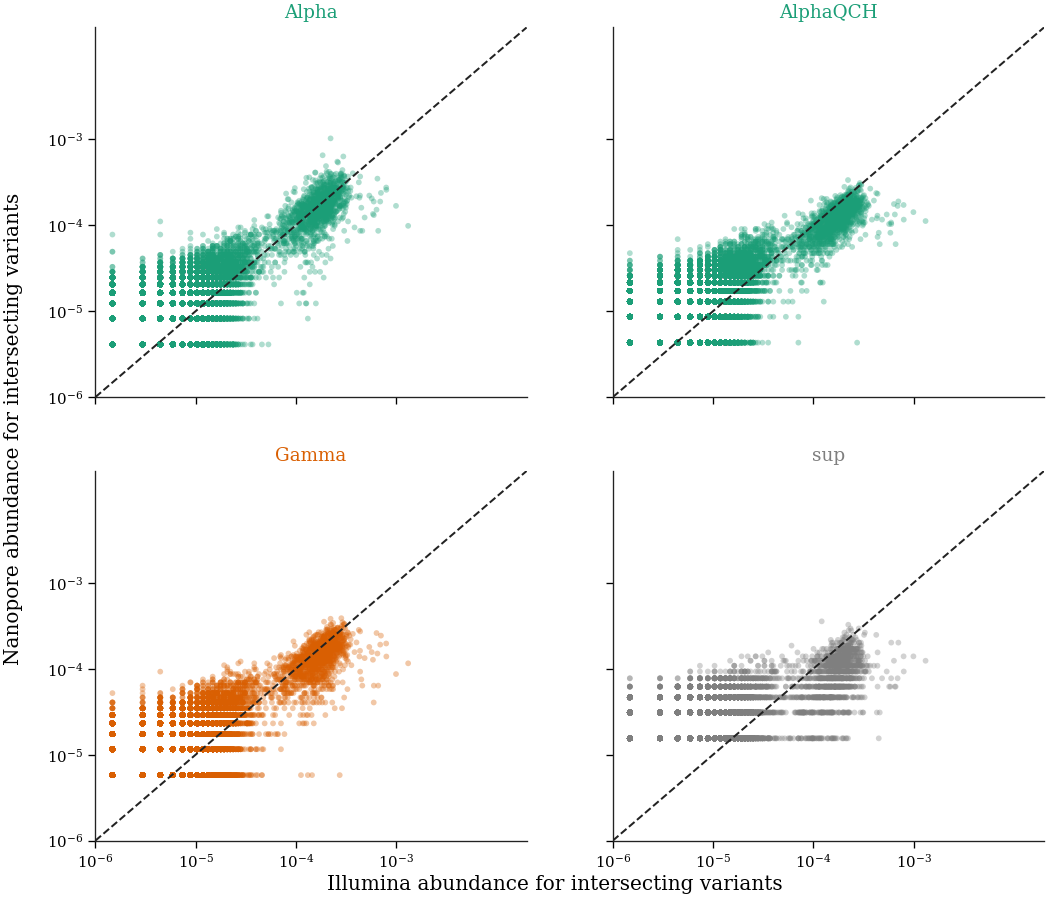

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P20 - Abundance concordance for intersecting variants.svg')

In [120]:
scatter_models = ["Alpha", "AlphaQCH", "Gamma", "sup"]
shared_variant_df = build_shared_variant_scatter(scatter_models, threshold=1, exclude_wt=True)
scatter_lower, scatter_upper, scatter_ticks = compute_shared_variant_scatter_axis(shared_variant_df)

fig, axes = plt.subplots(2, 2, figsize=(10.2, 8.8), sharex=True, sharey=True)
for plot_idx, (ax, model_name) in enumerate(zip(axes.flat, scatter_models)):
    subset = shared_variant_df[shared_variant_df["display_name"] == model_name].copy()
    draw_shared_variant_scatter_panel(
        ax,
        subset,
        model_name=model_name,
        lower=scatter_lower,
        upper=scatter_upper,
        ticks=scatter_ticks,
        title=model_name,
        x_label="",
        y_label="",
    )
    if plot_idx < 2:
        ax.tick_params(labelbottom=False)
    if plot_idx % 2 == 1:
        ax.tick_params(labelleft=False)
fig.supxlabel("Illumina abundance for intersecting variants", y=0.06)
fig.supylabel("Nanopore abundance for intersecting variants", x=0.05)
finalize_panel(fig, "P20 - Abundance concordance for intersecting variants")

## P30 - Intersecting variants vs retained variant count

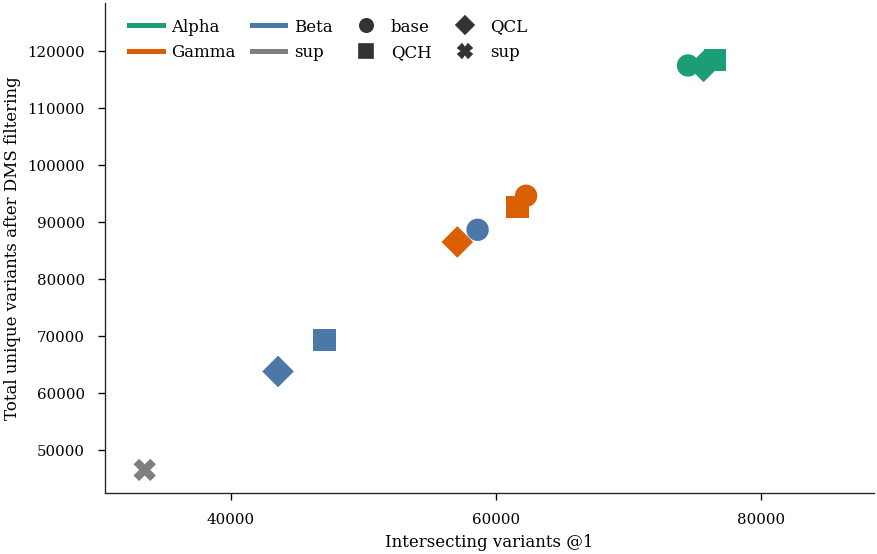

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P30 - Intersecting variants vs retained variant count.svg')

In [24]:
plot_df = model_summary_df[model_summary_df["display_name"].isin(MODEL_ONLY_ORDER)].copy()
family_handles, variant_handles = build_legend_handles(include_reference=False)

fig, ax = plt.subplots(figsize=(8.27, 5.3))
for _, row in plot_df.iterrows():
    ax.scatter(
        row["intersection_variants_1"],
        row["unique_variants"],
        s=MODEL_MARKER_SIZE,
        color=family_color(row["family"]),
        marker=VARIANT_MARKERS[row["variant"]],
        edgecolors="none",
    )
ax.set_xlabel("Intersecting variants @1")
ax.set_ylabel("Total unique variants after DMS filtering")
ax.set_xlim(plot_df["intersection_variants_1"].min() - 3000, plot_df["intersection_variants_1"].max() + 12000)
ax.set_ylim(plot_df["unique_variants"].min() - 4000, plot_df["unique_variants"].max() + 10000)
ax.set_xticks([40000, 60000, 80000])
ax.tick_params(axis="x", pad=8)
ax.tick_params(axis="y", pad=8)
fig.legend(
    handles=family_handles + variant_handles,
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.35, 0.88),
    columnspacing=1.0,
    handletextpad=0.5,
)
finalize_panel(fig, "P30 - Intersecting variants vs retained variant count")

## P31 - Weighted Jaccard

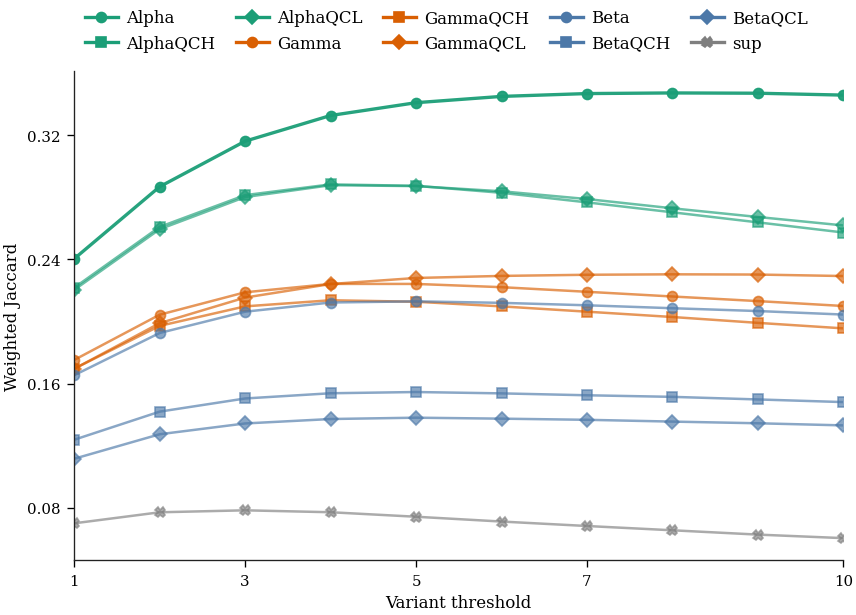

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P31 - Weighted Jaccard.svg')

In [36]:
robustness_df = threshold_long_df[threshold_long_df["display_name"].isin(MODEL_ONLY_ORDER)].copy()
model_lookup = model_summary_df.set_index("display_name")
legend_handles = build_threshold_robustness_legend_handles(model_lookup)
panel_title = "Weighted Jaccard"

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_threshold_robustness_panel(
    ax,
    robustness_df,
    model_lookup,
    metric="weighted_jaccard",
    label=panel_title,
)
fig.legend(
    handles=legend_handles,
    frameon=False,
    ncol=5,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    columnspacing=1.2,
    handletextpad=0.5,
)
finalize_panel(fig, "P31 - Weighted Jaccard")


## P32 - Jensen-Shannon Similarity

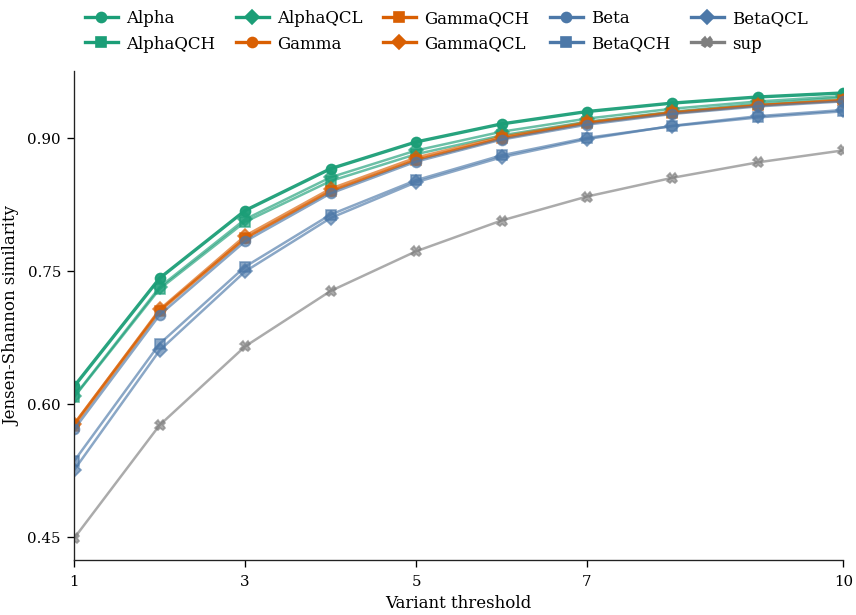

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P32 - Jensen-Shannon Similarity.svg')

In [42]:
robustness_df = threshold_long_df[threshold_long_df["display_name"].isin(MODEL_ONLY_ORDER)].copy()
model_lookup = model_summary_df.set_index("display_name")
legend_handles = build_threshold_robustness_legend_handles(model_lookup)
panel_title = "Jensen-Shannon similarity"

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_threshold_robustness_panel(
    ax,
    robustness_df,
    model_lookup,
    metric="jensen_shannon_similarity",
    label=panel_title,
)
fig.legend(
    handles=legend_handles,
    frameon=False,
    ncol=5,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    columnspacing=1.2,
    handletextpad=0.5,
)
finalize_panel(fig, "P32 - Jensen-Shannon Similarity")


## P33 - Exact overlap mass

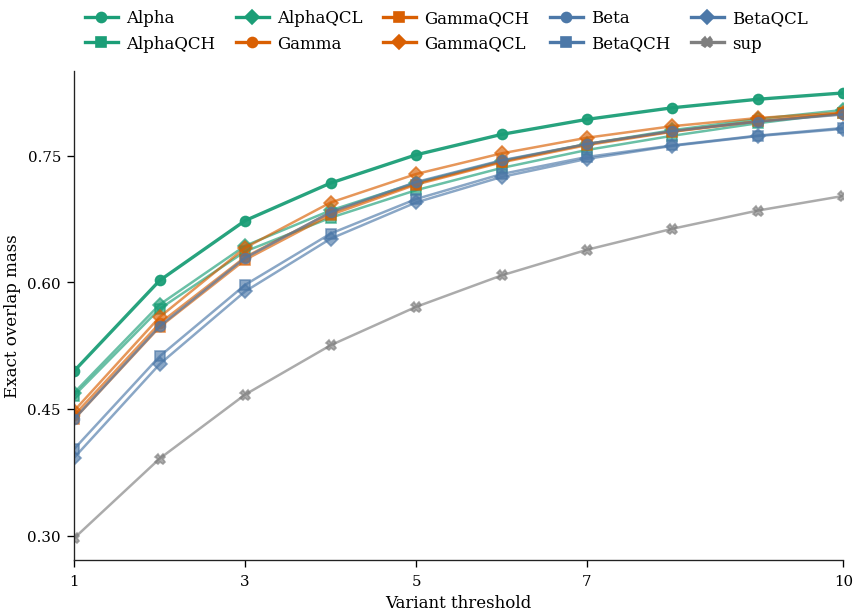

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P33 - Exact overlap mass.svg')

In [41]:
robustness_df = threshold_long_df[threshold_long_df["display_name"].isin(MODEL_ONLY_ORDER)].copy()
model_lookup = model_summary_df.set_index("display_name")
legend_handles = build_threshold_robustness_legend_handles(model_lookup)
panel_title = "Exact overlap mass"

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_threshold_robustness_panel(
    ax,
    robustness_df,
    model_lookup,
    metric="exact_overlap_mass",
    label=panel_title,
)
fig.legend(
    handles=legend_handles,
    frameon=False,
    ncol=5,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    columnspacing=1.2,
    handletextpad=0.5,
)
finalize_panel(fig, "P33 - Exact overlap mass")

## P34 - Variant precision

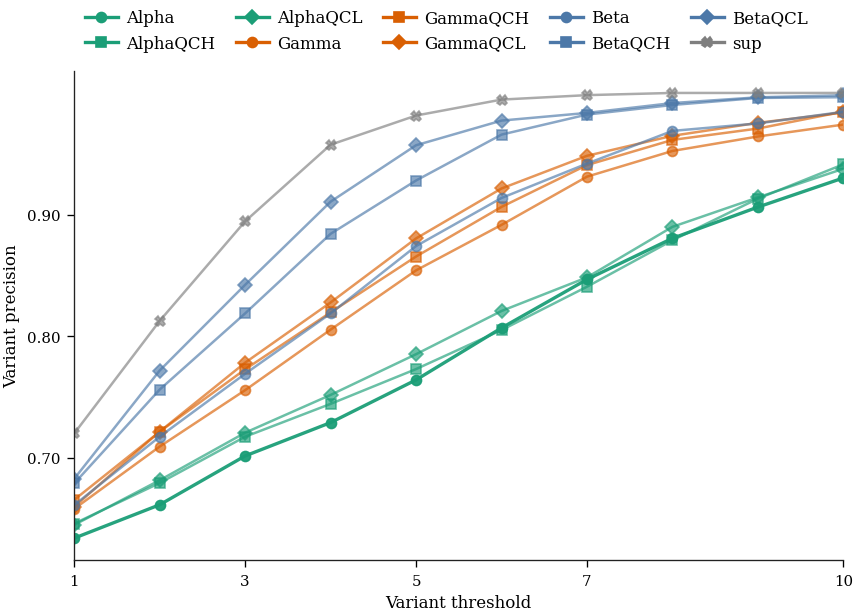

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P34 - Variant precision.svg')

In [40]:
robustness_df = threshold_long_df[threshold_long_df["display_name"].isin(MODEL_ONLY_ORDER)].copy()
model_lookup = model_summary_df.set_index("display_name")
legend_handles = build_threshold_robustness_legend_handles(model_lookup)
panel_title = "Variant precision"

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_threshold_robustness_panel(
    ax,
    robustness_df,
    model_lookup,
    metric="precision",
    label=panel_title,
)
fig.legend(
    handles=legend_handles,
    frameon=False,
    ncol=5,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    columnspacing=1.2,
    handletextpad=0.5,
)
finalize_panel(fig, "P34 - Variant precision")


## P35 - Variant recall

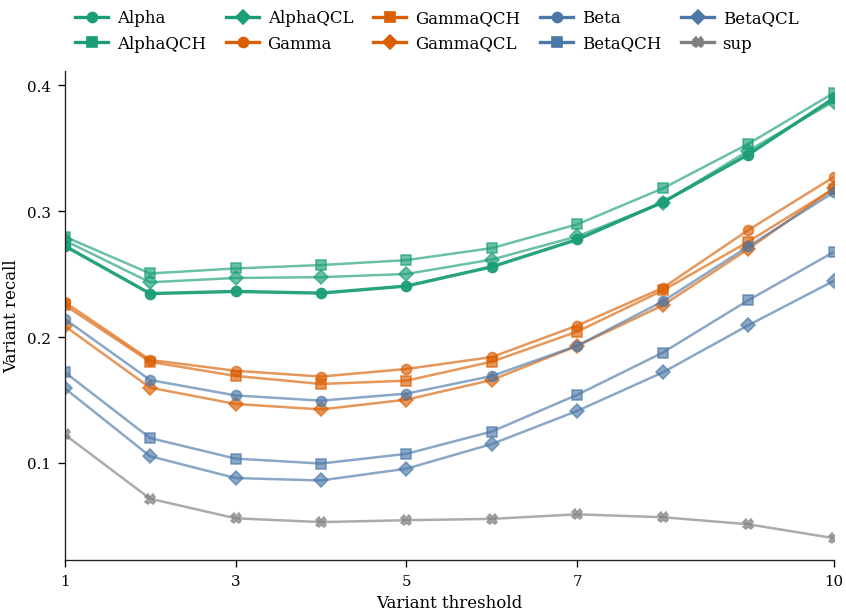

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P35 - Variant recall.svg')

In [43]:
robustness_df = threshold_long_df[threshold_long_df["display_name"].isin(MODEL_ONLY_ORDER)].copy()
model_lookup = model_summary_df.set_index("display_name")
legend_handles = build_threshold_robustness_legend_handles(model_lookup)
panel_title = "Variant recall"

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_threshold_robustness_panel(
    ax,
    robustness_df,
    model_lookup,
    metric="recall",
    label=panel_title,
)
fig.legend(
    handles=legend_handles,
    frameon=False,
    ncol=5,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    columnspacing=1.2,
    handletextpad=0.5,
)
finalize_panel(fig, "P35 - Variant recall")


## P36 - Variant F1 score

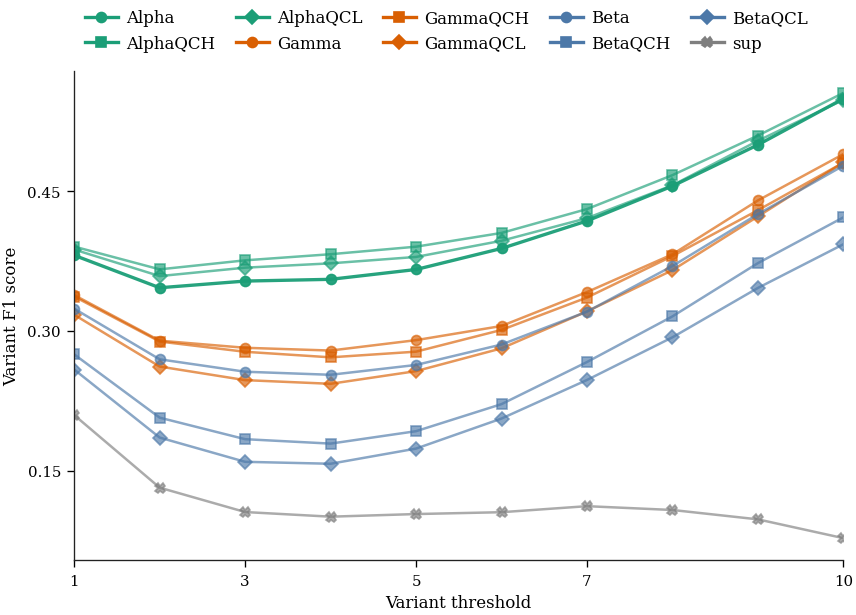

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P36 - Variant F1 score.svg')

In [44]:
robustness_df = threshold_long_df[threshold_long_df["display_name"].isin(MODEL_ONLY_ORDER)].copy()
model_lookup = model_summary_df.set_index("display_name")
legend_handles = build_threshold_robustness_legend_handles(model_lookup)
panel_title = "Variant F1 score"

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_threshold_robustness_panel(
    ax,
    robustness_df,
    model_lookup,
    metric="f1",
    label=panel_title,
)
fig.legend(
    handles=legend_handles,
    frameon=False,
    ncol=5,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    columnspacing=1.2,
    handletextpad=0.5,
)
finalize_panel(fig, "P36 - Variant F1 score")


## P37 - Number of intersecting variants

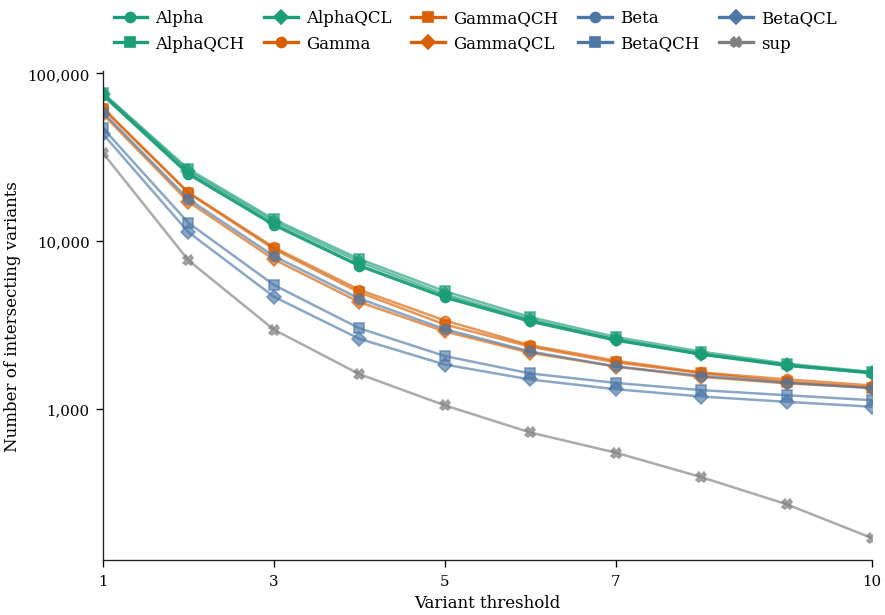

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P37 - Number of intersecting variants.svg')

In [45]:
robustness_df = threshold_long_df[threshold_long_df["display_name"].isin(MODEL_ONLY_ORDER)].copy()
model_lookup = model_summary_df.set_index("display_name")
legend_handles = build_threshold_robustness_legend_handles(model_lookup)
panel_title = "Number of intersecting variants"

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_threshold_robustness_panel(
    ax,
    robustness_df,
    model_lookup,
    metric="intersection_variants",
    label=panel_title,
)
fig.legend(
    handles=legend_handles,
    frameon=False,
    ncol=5,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    columnspacing=1.2,
    handletextpad=0.5,
)
finalize_panel(fig, "P37 - Number of intersecting variants")


## P38 - Composite concordance ranking

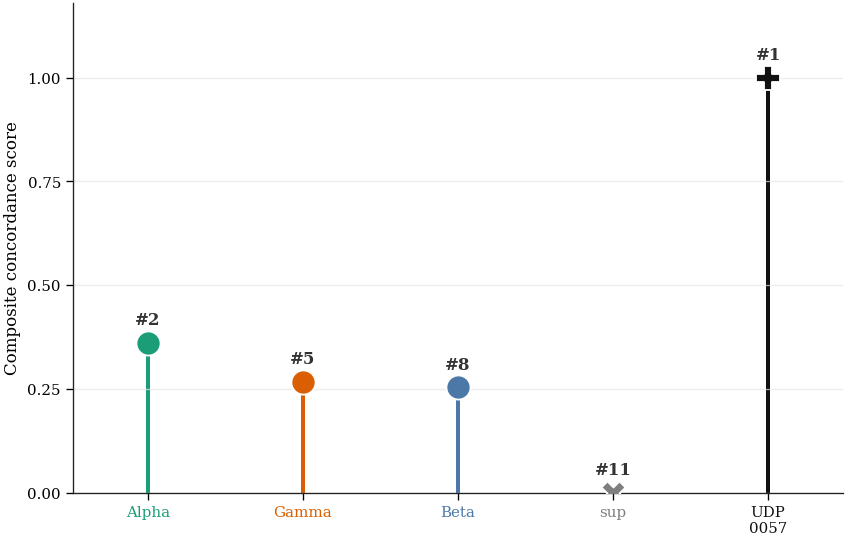

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P38 - Composite concordance ranking.svg')

In [ ]:
plot_3_10_auc_scores = compute_plot_3_10_auc_scores(threshold_long_df)
plot_3_10_scores = select_plot_3_10_models(plot_3_10_auc_scores)

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_plot_3_10_lollipop(ax, plot_3_10_scores)
finalize_panel(fig, "P38 - Composite concordance ranking")

## P40 - Normalised AUC component heatmap

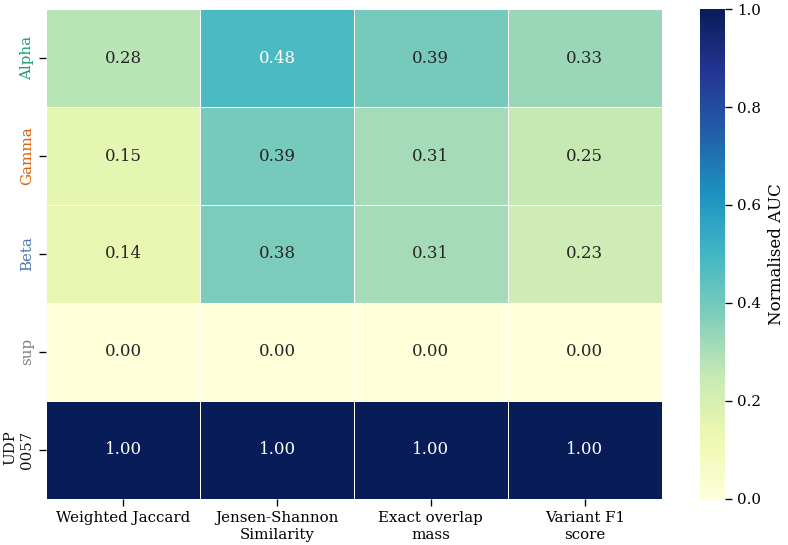

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P40 - Normalised AUC component heatmap.svg')

In [58]:
plot_3_10_auc_scores = compute_plot_3_10_auc_scores(threshold_long_df)
plot_3_10_scores = select_plot_3_10_models(plot_3_10_auc_scores)
plot_3_10_heatmap_df = build_plot_3_10_heatmap_df(plot_3_10_scores)

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_plot_3_10_heatmap(ax, plot_3_10_heatmap_df)
finalize_panel(fig, "P40 - Normalised AUC component heatmap")

## P42 - Intersecting variant abundance ECDF (model scale)

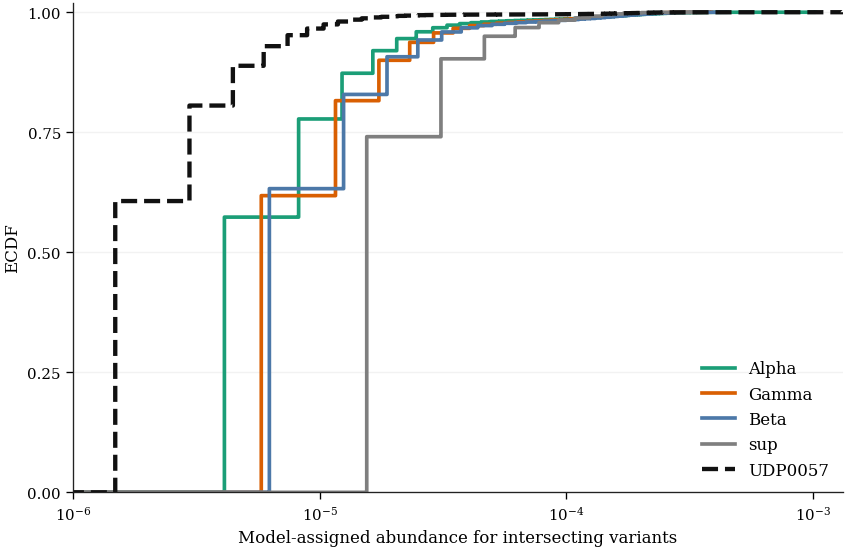

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P42 - Intersecting variant abundance ECDF (model scale).svg')

In [83]:
plot_3_10_auc_scores = compute_plot_3_10_auc_scores(threshold_long_df)
plot_3_10_scores = select_plot_3_10_models(plot_3_10_auc_scores)
plot_3_10_model_abundance_ecdf_df = build_plot_3_10_abundance_ecdf_df(plot_3_10_scores, abundance_source="model")
plot_3_10_model_axis_min, plot_3_10_model_axis_max, plot_3_10_model_axis_ticks = compute_plot_3_10_log_axis(
    plot_3_10_model_abundance_ecdf_df
)

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_plot_3_10_ecdf(
    ax,
    plot_3_10_scores,
    plot_3_10_model_abundance_ecdf_df,
    x_label="Model-assigned abundance for intersecting variants",
    axis_min=plot_3_10_model_axis_min,
    axis_max=plot_3_10_model_axis_max,
    axis_ticks=plot_3_10_model_axis_ticks,
    show_legend=True,
    legend_kwargs={
        "loc": "upper center",
        "bbox_to_anchor": (0.9, 0.3),
        "ncol": 1,
        "columnspacing": 1.3,
        "handlelength": 2.0,
    },
)
finalize_panel(fig, "P42 - Intersecting variant abundance ECDF (model scale)")


## P44 - Intersecting-variant abundance ECDF (ground-truth scale)

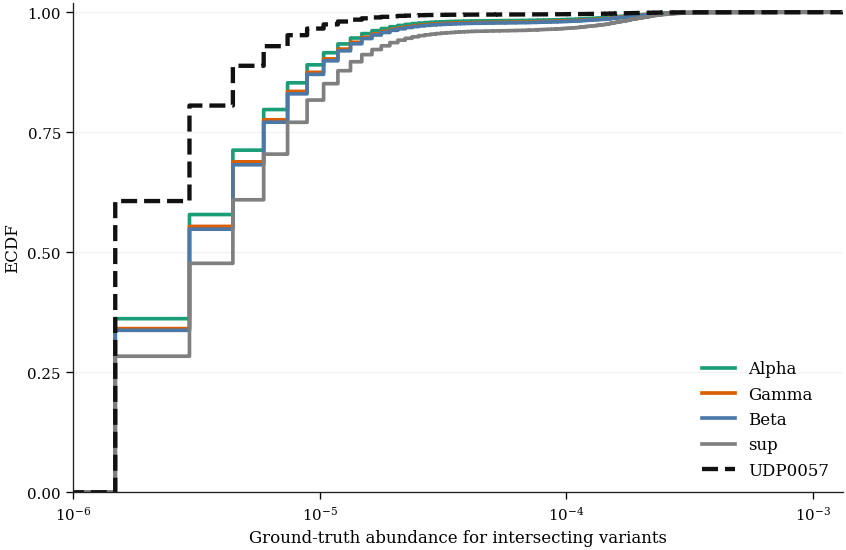

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P44 - Intersecting-variant abundance ECDF (ground-truth scale).svg')

In [92]:
plot_3_10_auc_scores = compute_plot_3_10_auc_scores(threshold_long_df)
plot_3_10_scores = select_plot_3_10_models(plot_3_10_auc_scores)
plot_3_10_truth_abundance_ecdf_df = build_plot_3_10_abundance_ecdf_df(plot_3_10_scores, abundance_source="ground_truth")
plot_3_10_truth_axis_min, plot_3_10_truth_axis_max, plot_3_10_truth_axis_ticks = compute_plot_3_10_log_axis(
    plot_3_10_truth_abundance_ecdf_df
)

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_plot_3_10_ecdf(
    ax,
    plot_3_10_scores,
    plot_3_10_truth_abundance_ecdf_df,
    x_label="Ground-truth abundance for intersecting variants",
    axis_min=plot_3_10_truth_axis_min,
    axis_max=plot_3_10_truth_axis_max,
    axis_ticks=plot_3_10_truth_axis_ticks,
    show_legend=True,
    legend_kwargs={
        "loc": "upper center",
        "bbox_to_anchor": (0.9, 0.3),
        "ncol": 1,
        "columnspacing": 1.3,
        "handlelength": 2.0,
    },
)
finalize_panel(fig, "P44 - Intersecting-variant abundance ECDF (ground-truth scale)")


## P20 - Abundance concordance for intersecting variants (Alpha)

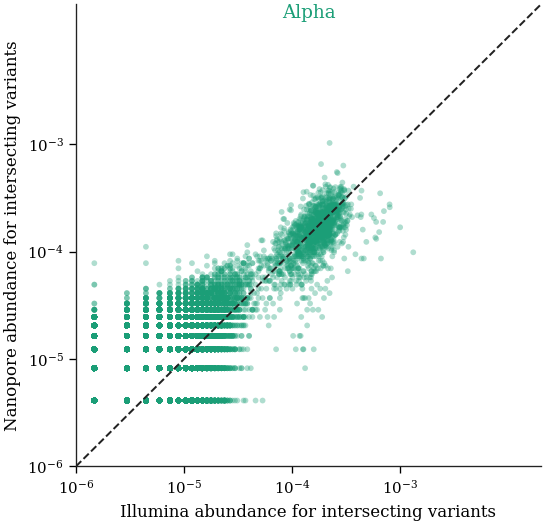

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P20 - Abundance concordance for intersecting variants (Alpha).svg')

In [12]:
supplementary_shared_df = build_shared_variant_scatter(MODEL_ONLY_ORDER, threshold=1, exclude_wt=True)
supplementary_lower, supplementary_upper, supplementary_ticks = compute_shared_variant_scatter_axis(supplementary_shared_df)
subset = supplementary_shared_df[supplementary_shared_df["display_name"] == "Alpha"].copy()
panel_title = "Alpha"

fig, ax = plt.subplots(figsize=(5, 5))
draw_shared_variant_scatter_panel(
    ax,
    subset,
    model_name="Alpha",
    lower=supplementary_lower,
    upper=supplementary_upper,
    ticks=supplementary_ticks,
    title=panel_title,
    x_label="Illumina abundance for intersecting variants",
    y_label="Nanopore abundance for intersecting variants",
)
finalize_panel(fig, "P20 - Abundance concordance for intersecting variants (Alpha)")

## P21 - Abundance concordance for intersecting variants (AlphaQCH)

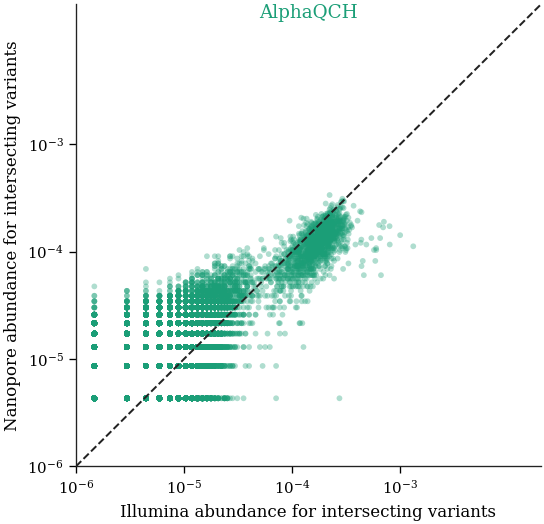

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P21 - Abundance concordance for intersecting variants (AlphaQCH).svg')

In [11]:
supplementary_shared_df = build_shared_variant_scatter(MODEL_ONLY_ORDER, threshold=1, exclude_wt=True)
supplementary_lower, supplementary_upper, supplementary_ticks = compute_shared_variant_scatter_axis(supplementary_shared_df)
subset = supplementary_shared_df[supplementary_shared_df["display_name"] == "AlphaQCH"].copy()
panel_title = "AlphaQCH"

fig, ax = plt.subplots(figsize=(5, 5))
draw_shared_variant_scatter_panel(
    ax,
    subset,
    model_name="AlphaQCH",
    lower=supplementary_lower,
    upper=supplementary_upper,
    ticks=supplementary_ticks,
    title=panel_title,
    x_label="Illumina abundance for intersecting variants",
    y_label="Nanopore abundance for intersecting variants",
)
finalize_panel(fig, "P21 - Abundance concordance for intersecting variants (AlphaQCH)")

## P22 - Abundance concordance for intersecting variants (AlphaQCL)

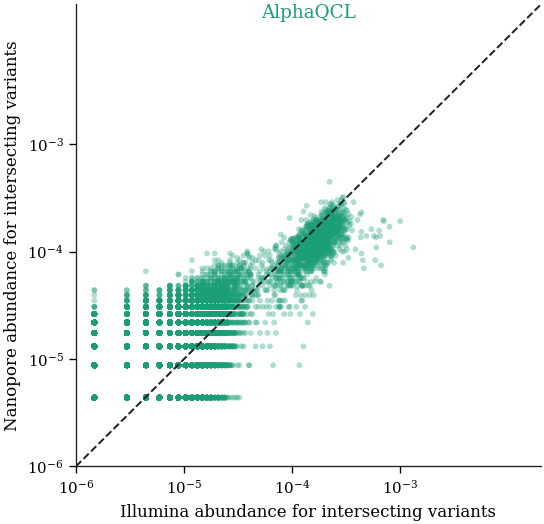

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P22 - Abundance concordance for intersecting variants (AlphaQCL).svg')

In [10]:
supplementary_shared_df = build_shared_variant_scatter(MODEL_ONLY_ORDER, threshold=1, exclude_wt=True)
supplementary_lower, supplementary_upper, supplementary_ticks = compute_shared_variant_scatter_axis(supplementary_shared_df)
subset = supplementary_shared_df[supplementary_shared_df["display_name"] == "AlphaQCL"].copy()
panel_title = "AlphaQCL"

fig, ax = plt.subplots(figsize=(5, 5))
draw_shared_variant_scatter_panel(
    ax,
    subset,
    model_name="AlphaQCL",
    lower=supplementary_lower,
    upper=supplementary_upper,
    ticks=supplementary_ticks,
    title=panel_title,
    x_label="Illumina abundance for intersecting variants",
    y_label="Nanopore abundance for intersecting variants",
)
finalize_panel(fig, "P22 - Abundance concordance for intersecting variants (AlphaQCL)")

## P23 - Abundance concordance for intersecting variants (Gamma)

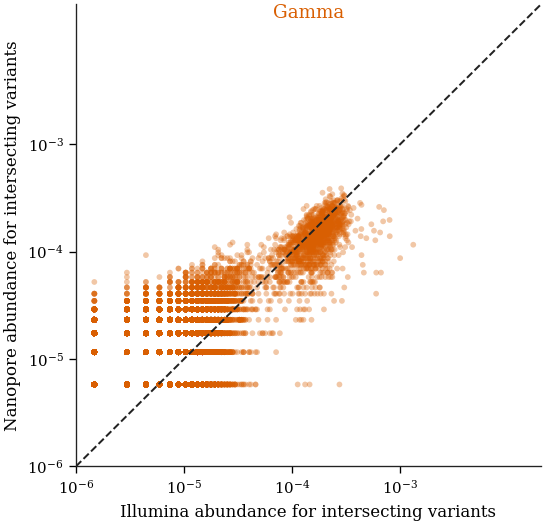

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P23 - Abundance concordance for intersecting variants (Gamma).svg')

In [9]:
supplementary_shared_df = build_shared_variant_scatter(MODEL_ONLY_ORDER, threshold=1, exclude_wt=True)
supplementary_lower, supplementary_upper, supplementary_ticks = compute_shared_variant_scatter_axis(supplementary_shared_df)
subset = supplementary_shared_df[supplementary_shared_df["display_name"] == "Gamma"].copy()
panel_title = "Gamma"

fig, ax = plt.subplots(figsize=(5, 5))
draw_shared_variant_scatter_panel(
    ax,
    subset,
    model_name="Gamma",
    lower=supplementary_lower,
    upper=supplementary_upper,
    ticks=supplementary_ticks,
    title=panel_title,
    x_label="Illumina abundance for intersecting variants",
    y_label="Nanopore abundance for intersecting variants",
)
finalize_panel(fig, "P23 - Abundance concordance for intersecting variants (Gamma)")


## P24 - Abundance concordance for intersecting variants (GammaQCH)

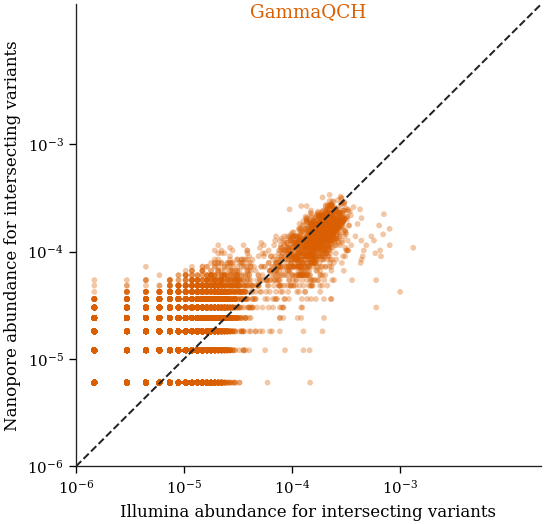

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P24 - Abundance concordance for intersecting variants (GammaQCH).svg')

In [8]:
supplementary_shared_df = build_shared_variant_scatter(MODEL_ONLY_ORDER, threshold=1, exclude_wt=True)
supplementary_lower, supplementary_upper, supplementary_ticks = compute_shared_variant_scatter_axis(supplementary_shared_df)
subset = supplementary_shared_df[supplementary_shared_df["display_name"] == "GammaQCH"].copy()
panel_title = "GammaQCH"

fig, ax = plt.subplots(figsize=(5, 5))
draw_shared_variant_scatter_panel(
    ax,
    subset,
    model_name="GammaQCH",
    lower=supplementary_lower,
    upper=supplementary_upper,
    ticks=supplementary_ticks,
    title=panel_title,
    x_label="Illumina abundance for intersecting variants",
    y_label="Nanopore abundance for intersecting variants",
)
finalize_panel(fig, "P24 - Abundance concordance for intersecting variants (GammaQCH)")

## P25 - Abundance concordance for intersecting variants (GammaQCL)

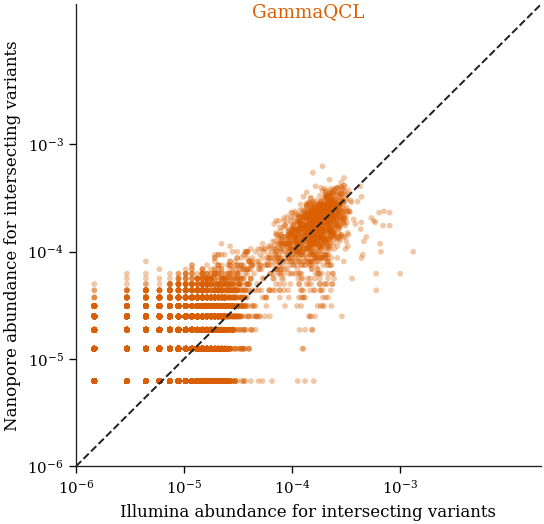

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P25 - Abundance concordance for intersecting variants (GammaQCL).svg')

In [6]:
supplementary_shared_df = build_shared_variant_scatter(MODEL_ONLY_ORDER, threshold=1, exclude_wt=True)
supplementary_lower, supplementary_upper, supplementary_ticks = compute_shared_variant_scatter_axis(supplementary_shared_df)
subset = supplementary_shared_df[supplementary_shared_df["display_name"] == "GammaQCL"].copy()
panel_title = "GammaQCL"

fig, ax = plt.subplots(figsize=(5, 5))
draw_shared_variant_scatter_panel(
    ax,
    subset,
    model_name="GammaQCL",
    lower=supplementary_lower,
    upper=supplementary_upper,
    ticks=supplementary_ticks,
    title=panel_title,
    x_label="Illumina abundance for intersecting variants",
    y_label="Nanopore abundance for intersecting variants",
)
finalize_panel(fig, "P25 - Abundance concordance for intersecting variants (GammaQCL)")

## P26 - Abundance concordance for intersecting variants (Beta)

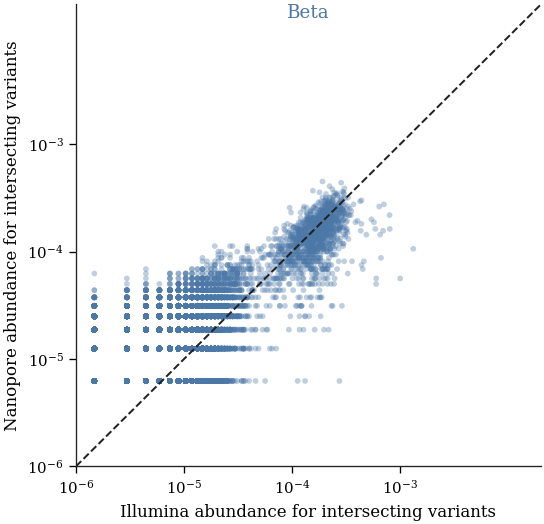

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P26 - Abundance concordance for intersecting variants (Beta).svg')

In [7]:
supplementary_shared_df = build_shared_variant_scatter(MODEL_ONLY_ORDER, threshold=1, exclude_wt=True)
supplementary_lower, supplementary_upper, supplementary_ticks = compute_shared_variant_scatter_axis(supplementary_shared_df)
subset = supplementary_shared_df[supplementary_shared_df["display_name"] == "Beta"].copy()
panel_title = "Beta"

fig, ax = plt.subplots(figsize=(5, 5))
draw_shared_variant_scatter_panel(
    ax,
    subset,
    model_name="Beta",
    lower=supplementary_lower,
    upper=supplementary_upper,
    ticks=supplementary_ticks,
    title=panel_title,
    x_label="Illumina abundance for intersecting variants",
    y_label="Nanopore abundance for intersecting variants",
)
finalize_panel(fig, "P26 - Abundance concordance for intersecting variants (Beta)")


## P27 - Abundance concordance for intersecting variants (BetaQCH)

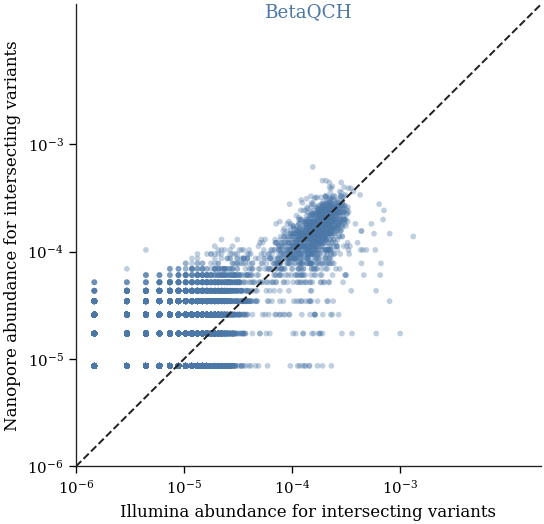

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P27 - Abundance concordance for intersecting variants (BetaQCH).svg')

In [13]:
supplementary_shared_df = build_shared_variant_scatter(MODEL_ONLY_ORDER, threshold=1, exclude_wt=True)
supplementary_lower, supplementary_upper, supplementary_ticks = compute_shared_variant_scatter_axis(supplementary_shared_df)
subset = supplementary_shared_df[supplementary_shared_df["display_name"] == "BetaQCH"].copy()
panel_title = "BetaQCH"

fig, ax = plt.subplots(figsize=(5,5))
draw_shared_variant_scatter_panel(
    ax,
    subset,
    model_name="BetaQCH",
    lower=supplementary_lower,
    upper=supplementary_upper,
    ticks=supplementary_ticks,
    title=panel_title,
    x_label="Illumina abundance for intersecting variants",
    y_label="Nanopore abundance for intersecting variants",
)
finalize_panel(fig, "P27 - Abundance concordance for intersecting variants (BetaQCH)")


## P28 - Abundance concordance for intersecting variants (BetaQCL)

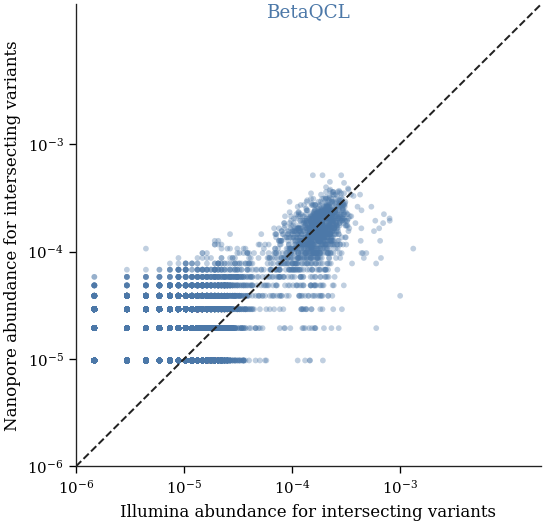

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P28 - Abundance concordance for intersecting variants (BetaQCL).svg')

In [15]:
supplementary_shared_df = build_shared_variant_scatter(MODEL_ONLY_ORDER, threshold=1, exclude_wt=True)
supplementary_lower, supplementary_upper, supplementary_ticks = compute_shared_variant_scatter_axis(supplementary_shared_df)
subset = supplementary_shared_df[supplementary_shared_df["display_name"] == "BetaQCL"].copy()
panel_title = "BetaQCL"

fig, ax = plt.subplots(figsize=(5, 5))
draw_shared_variant_scatter_panel(
    ax,
    subset,
    model_name="BetaQCL",
    lower=supplementary_lower,
    upper=supplementary_upper,
    ticks=supplementary_ticks,
    title=panel_title,
    x_label="Illumina abundance for intersecting variants",
    y_label="Nanopore abundance for intersecting variants",
)
finalize_panel(fig, "P28 - Abundance concordance for intersecting variants (BetaQCL)")


## P29 - Abundance concordance for intersecting variants (Sup)

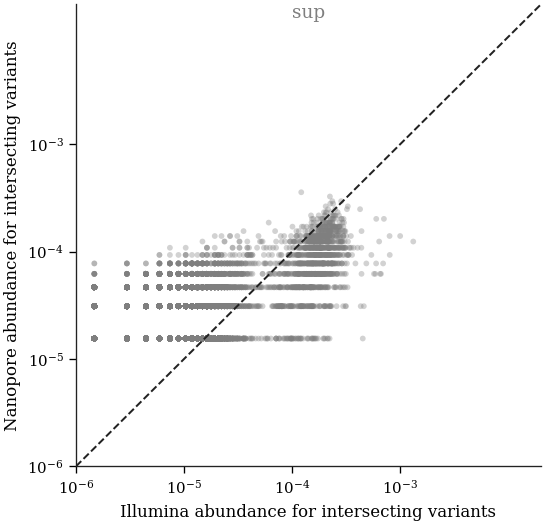

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P29 - Abundance concordance for intersecting variants (Sup).svg')

In [16]:
supplementary_shared_df = build_shared_variant_scatter(MODEL_ONLY_ORDER, threshold=1, exclude_wt=True)
supplementary_lower, supplementary_upper, supplementary_ticks = compute_shared_variant_scatter_axis(supplementary_shared_df)
subset = supplementary_shared_df[supplementary_shared_df["display_name"] == "sup"].copy()
panel_title = "sup"

fig, ax = plt.subplots(figsize=(5,5))
draw_shared_variant_scatter_panel(
    ax,
    subset,
    model_name="sup",
    lower=supplementary_lower,
    upper=supplementary_upper,
    ticks=supplementary_ticks,
    title=panel_title,
    x_label="Illumina abundance for intersecting variants",
    y_label="Nanopore abundance for intersecting variants",
)
finalize_panel(fig, "P29 - Abundance concordance for intersecting variants (Sup)")


## P39 - Composite concordance ranking (all models)

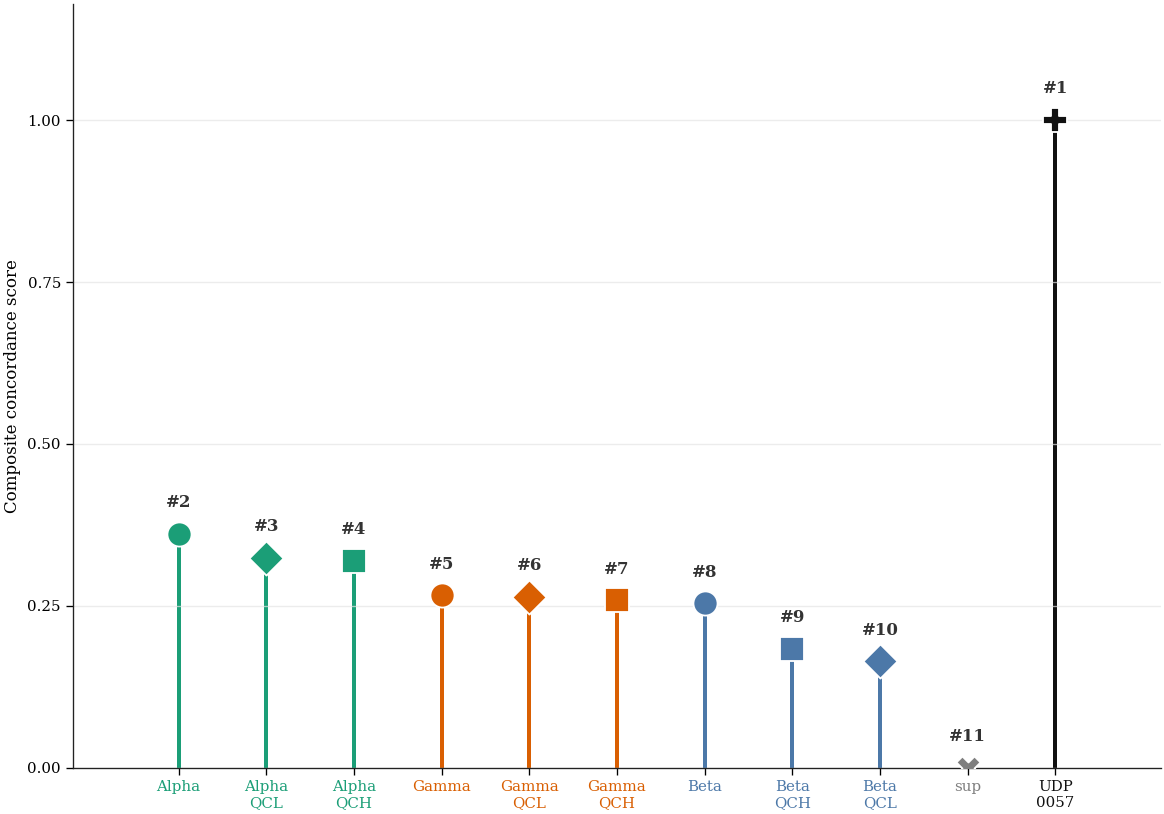

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P39 - Composite concordance ranking (all models).svg')

In [62]:
supplementary_plot_p2_scores = select_plot_3_10_all_models(compute_plot_3_10_auc_scores(threshold_long_df))
fig, ax = plt.subplots(figsize=(11.69,8.27))
draw_plot_3_10_lollipop(ax, supplementary_plot_p2_scores)
finalize_panel(fig, "P39 - Composite concordance ranking (all models)")

## P41 - Normalised AUC component heatmap (all models)

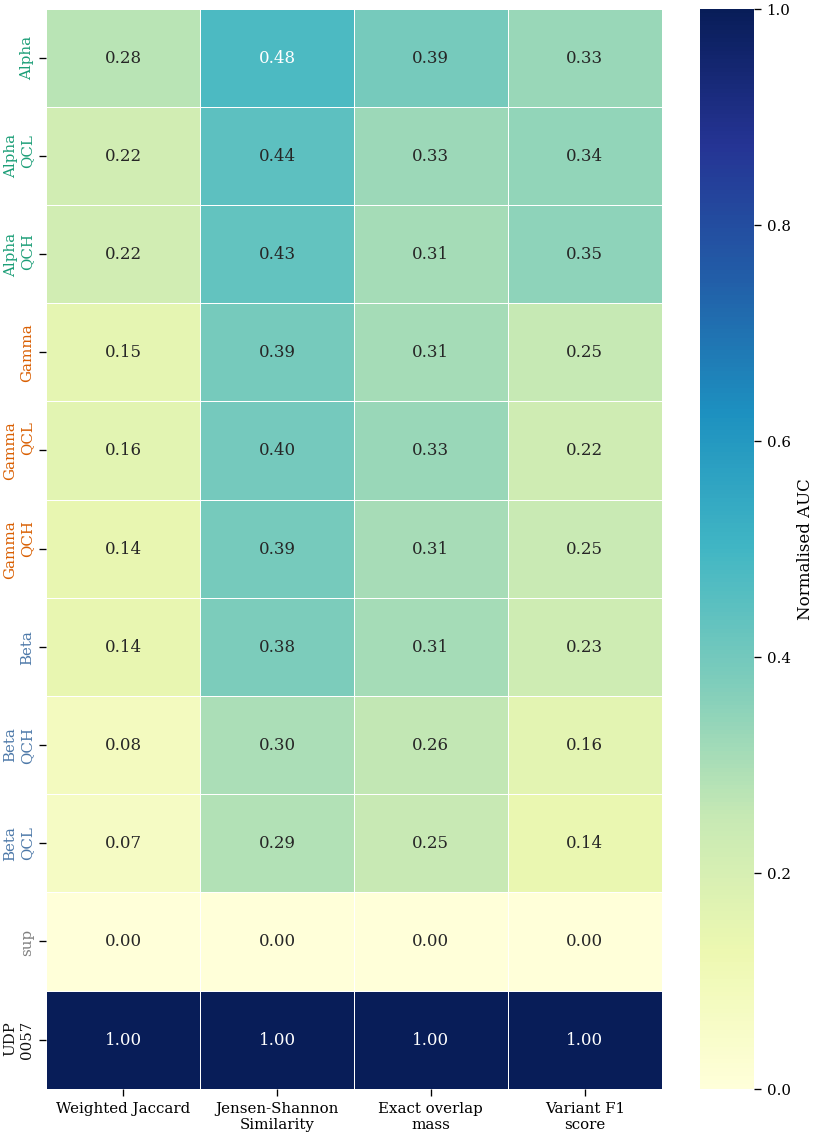

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P41 - Normalised AUC component heatmap (all models).svg')

In [60]:
supplementary_plot_p3_scores = select_plot_3_10_all_models(compute_plot_3_10_auc_scores(threshold_long_df))
supplementary_plot_p3_heatmap_df = build_plot_3_10_heatmap_df(supplementary_plot_p3_scores)

fig, ax = plt.subplots(figsize=(8.27, 11.69))
draw_plot_3_10_heatmap(ax, supplementary_plot_p3_heatmap_df)
finalize_panel(fig, "P41 - Normalised AUC component heatmap (all models)")

## P43 - Intersecting-variant abundance ECDF (model scale, all models)

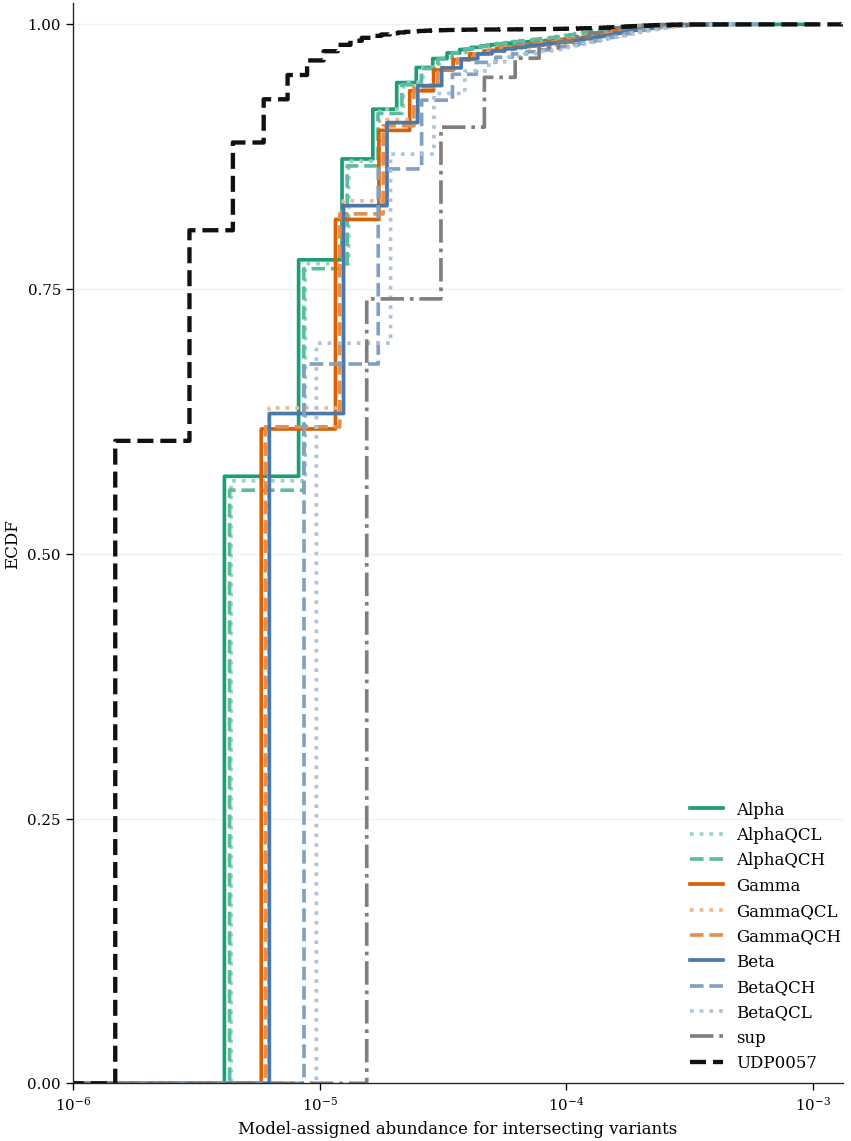

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P43 - Intersecting-variant abundance ECDF (model scale, all models).svg')

In [96]:
supplementary_plot_p4_scores = select_plot_3_10_all_models(compute_plot_3_10_auc_scores(threshold_long_df))
supplementary_plot_p4_ecdf_df = build_plot_3_10_abundance_ecdf_df(supplementary_plot_p4_scores, abundance_source="model")
supplementary_plot_p4_axis_min, supplementary_plot_p4_axis_max, supplementary_plot_p4_axis_ticks = compute_plot_3_10_log_axis(
    supplementary_plot_p4_ecdf_df
)

fig, ax = plt.subplots(figsize=(8.27, 11.69))
draw_plot_3_10_ecdf(
    ax,
    supplementary_plot_p4_scores,
    supplementary_plot_p4_ecdf_df,
    x_label="Model-assigned abundance for intersecting variants",
    axis_min=supplementary_plot_p4_axis_min,
    axis_max=supplementary_plot_p4_axis_max,
    axis_ticks=supplementary_plot_p4_axis_ticks,
    show_legend=True,
    distinguish_variants=True,
    legend_kwargs={
        "loc": "upper center",
        "bbox_to_anchor": (0.9, 0.275),
        "ncol": 1,
        "columnspacing": 1.3,
        "handlelength": 2.0,
    },
)
finalize_panel(fig, "P43 - Intersecting-variant abundance ECDF (model scale, all models)")


## P45 - Intersecting-variant abundance ECDF (ground-truth scale, all models)

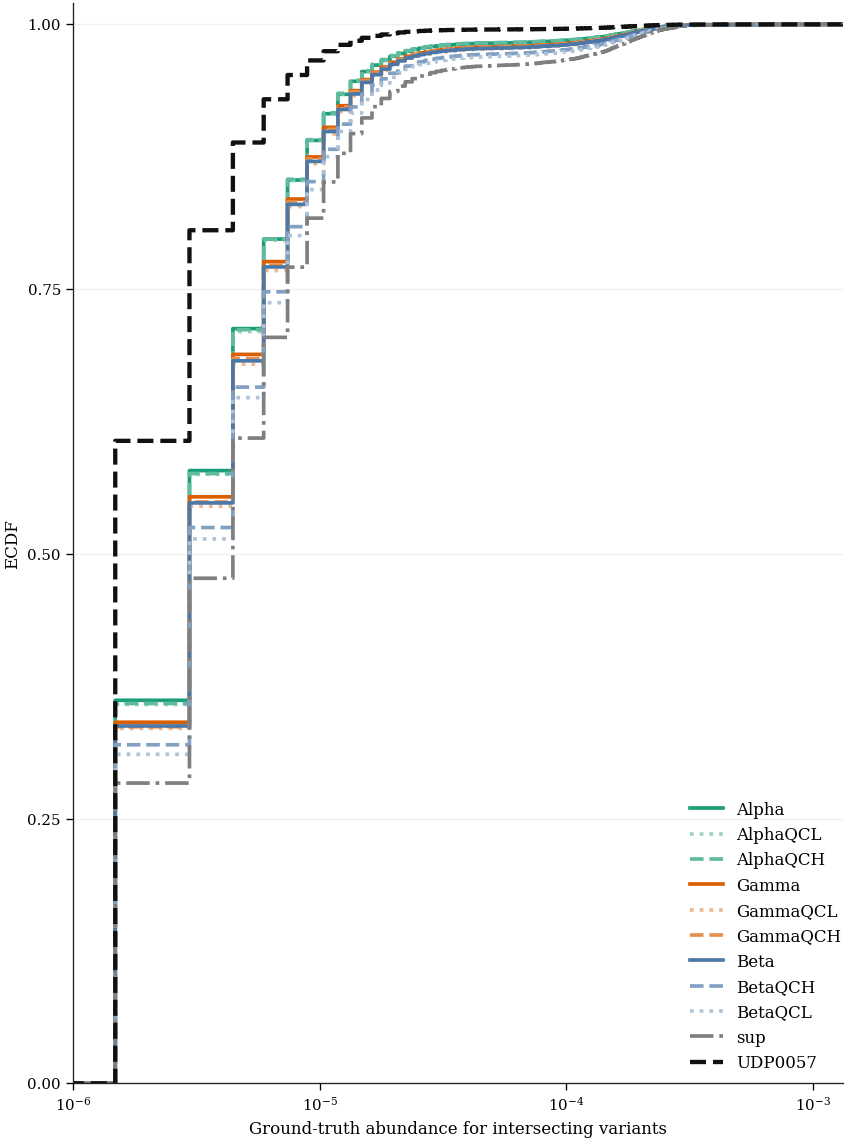

PosixPath('/home/kang/experimental/COMPX593-Thesis/plot/panels/P45 - Intersecting-variant abundance ECDF (ground-truth scale, all models).svg')

In [95]:
supplementary_plot_p5_scores = select_plot_3_10_all_models(compute_plot_3_10_auc_scores(threshold_long_df))
supplementary_plot_p5_ecdf_df = build_plot_3_10_abundance_ecdf_df(supplementary_plot_p5_scores, abundance_source="ground_truth")
supplementary_plot_p5_axis_min, supplementary_plot_p5_axis_max, supplementary_plot_p5_axis_ticks = compute_plot_3_10_log_axis(
    supplementary_plot_p5_ecdf_df
)

fig, ax = plt.subplots(figsize=(8.27, 11.69))
draw_plot_3_10_ecdf(
    ax,
    supplementary_plot_p5_scores,
    supplementary_plot_p5_ecdf_df,
    x_label="Ground-truth abundance for intersecting variants",
    axis_min=supplementary_plot_p5_axis_min,
    axis_max=supplementary_plot_p5_axis_max,
    axis_ticks=supplementary_plot_p5_axis_ticks,
    show_legend=True,
    distinguish_variants=True,
    legend_kwargs={
        "loc": "upper center",
        "bbox_to_anchor": (0.9, 0.275),
        "ncol": 1,
        "columnspacing": 1.3,
        "handlelength": 2.0,
    },
)
finalize_panel(fig, "P45 - Intersecting-variant abundance ECDF (ground-truth scale, all models)")
